# EDA ô tô VinFast — nguồn cung, giá chào bán và thông điệp quảng cáo

**Phạm vi:** bốn nội dung mô tả: (1) chất lượng dữ liệu, (2) cơ cấu nguồn cung,
(3) mặt bằng giá chào bán, (4) thông điệp bán hàng. Chỉ phân tích ô tô VinFast.

Không suy luận số người mua, giá giao dịch, tăng trưởng thị trường hoặc tốc độ bán từ một snapshot.
Không dùng ngày đăng hay thời gian sửa file làm `crawl_date`. Không suy tên brand/model xe máy từ văn bản.
Lọc hãng bằng `carbrand_name == VinFast` (không phân biệt hoa thường) và đối chiếu mã hãng.
Tên model lấy trực tiếp từ `carmodel_name`, không phân tích văn bản để gán model.
Notebook sử dụng bảng làm việc trong bộ nhớ; xe máy nằm ngoài phạm vi.

**Chạy lại:** Python với pandas, numpy, matplotlib, nbformat, nbclient, ipykernel.
Chạy các ô từ trên xuống từ thư mục dự án hoặc `data visualization/`. Ảnh PNG được lưu vào `figures/`.
Các CSV tham chiếu chỉ được kiểm tra chất lượng; không gộp vào tập Cho Tot để tính tỷ trọng/giá.

In [1]:
from pathlib import Path
import json, hashlib, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if not (ROOT / 'data' / 'raw').exists(): ROOT = ROOT.parent
assert (ROOT / 'data' / 'raw').exists(), 'Run from repository or data visualization/'
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
BLUE, TEAL, AMBER, INK, MUTED = '#2563EB', '#0D9488', '#D97706', '#172B4D', '#64748B'
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.spines.left':False, 'axes.spines.bottom':False,
    'figure.facecolor':'#F5F7FB', 'axes.facecolor':'#F5F7FB',
    'text.color':INK, 'axes.labelcolor':MUTED, 'xtick.color':MUTED, 'ytick.color':INK,
    'axes.titlesize':15, 'axes.titleweight':'bold', 'axes.titlelocation':'left',
    'axes.titlepad':20, 'axes.labelpad':12, 'xtick.major.size':0, 'ytick.major.size':0,
    'grid.color':'#DCE3EE', 'grid.linewidth':.7, 'axes.axisbelow':True,
    'legend.frameon':False, 'figure.dpi':120, 'savefig.dpi':180})
pd.set_option('display.max_columns', 20)
sources = sorted(p for d in ['raw','processed'] for p in (ROOT/'data'/d).rglob('*') if p.is_file())
hashes = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in sources}
tables = {}
for p in sources:
    tables[p.name] = pd.DataFrame(json.loads(p.read_text(encoding='utf-8-sig'))) if p.suffix == '.json' else pd.read_csv(p)
saved = []
def chart_label(value):
    text=str(value).replace('VinFast ','')
    translations={'Dòng khác':'Other models','Thiếu tên mẫu':'Unknown model',
        'Mới':'New','Đã sử dụng':'Used','Không rõ':'Unknown',
        'Nhắc kèm/mua pin':'Battery included / purchased',
        'Nhắc thuê pin':'Battery rental',
        'Nhắc trả góp/trả trước':'Financing / down payment',
        'Nhắc khuyến mãi':'Promotions',
        'Nhắc đổi xe xăng':'ICE vehicle trade-in',
        'Nhắc bảo hành/hậu mãi':'Warranty / after-sales'}
    if text in translations: return translations[text]
    text=text.replace('TP Hồ Chí Minh','Ho Chi Minh City').replace('TP Hà Nội','Hanoi')
    if text.startswith('TP '): text=text[3:]+' City'
    return ''.join(c for c in unicodedata.normalize('NFD',text.replace('Đ','D').replace('đ','d')) if unicodedata.category(c)!='Mn')
def save(fig, name):
    fig.tight_layout(rect=(0,.055,1,.98),pad=1.7)
    fig.text(.025,.014,'VINFAST  /  CARS     •     Source: Cho Tot listing sample     •     Asking prices, not transaction prices',
             fontsize=8.5,color=MUTED)
    path = FIG / (name + '.png')
    fig.savefig(path, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)
    saved.append(path)
    display(Image(filename=str(path)))
def note(text): display(Markdown(text))
def barh(series, title, xlabel, name, color=BLUE):
    s = series.sort_index() if name.endswith('_year') else series.sort_values()
    fig, ax = plt.subplots(figsize=(12, max(5, len(s)*.43+2)))
    labels=[chart_label(x) for x in s.index]
    bars=ax.barh(labels, s.values, color=[color if v==s.max() else '#8FB2EB' for v in s],height=.6)
    percentage='(%)' in xlabel
    ax.bar_label(bars,labels=[f'{v:.1f}%' if percentage else f'{v:,.0f}' for v in s],padding=9,fontsize=11,color=INK)
    ax.set(title=title, xlabel=xlabel)
    if name.endswith('_year'): ax.set_ylabel('Manufacturing year (YYYY)')
    ax.set_xlim(0,max(s.max()*1.17,1))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5,integer=not percentage))
    ax.grid(axis='x')
    save(fig, name)

## 1. Chất lượng dữ liệu và điều kiện sử dụng

Kiểm kê mọi nguồn; chỉ khử trùng bảng làm việc Cho Tot theo `list_id`, giữ lần xuất hiện đầu tiên
trong thứ tự nguồn. Đây là quy tắc tái lập, không có nghĩa bản giữ lại mới nhất.
ID thiếu không được đưa vào bảng làm việc. Không sửa file gốc. CSV B2C không có ID nên
trùng toàn dòng/tựa đề chỉ là tín hiệu lặp nội dung, không đủ căn cứ kết luận trùng listing.

,file,rows,columns,missing_listing_id,unique_listing_ids,duplicate_id_rows,exact_duplicate_rows
0,ev_market_cleaned.csv,1000,10,0.0,50.0,950.0,948
1,chotot_oto_raw.json,1000,100,0.0,1000.0,0.0,0
2,chotot_xemay_raw.json,1000,91,0.0,1000.0,0.0,0
3,ev_benchmark.csv,8,5,NaN,NaN,NaN,0
4,otodien_raw.csv,287,5,NaN,NaN,NaN,12
5,phoxedien_raw.csv,373,4,NaN,NaN,NaN,334
6,thegioixedien_raw.csv,43,4,NaN,NaN,NaN,0


**Phạm vi:** 1,000 dòng ô tô → 950 dòng VinFast; loại 50 dòng hãng khác khỏi EDA. Xe máy không tham gia.

,carbrand,carbrand_name
0,80,VinFast


**Ô tô VinFast:** 950 dòng → **950 listing** sau quy tắc ID; chưa lọc theo giá/ODO.

**10 tin ngẫu nhiên kiểm tra nhãn nguồn (seed=42):**

,list_id,subject,brand_code,model_code,brand,model
208,134601695,"VinFast VF2 Ô tô điện Đỏ, Trắng, Xanh",80,1348,VinFast,VinFast VF2
978,132774974,"VF7, vay 85-100%, áp Voucher Lux SA 80t, còn 635t",80,1189,VinFast,VinFast VF7
729,134464520,Giá lăn bánh Vinfast VF6. Xe sẵn giao ngay,80,1185,VinFast,VinFast VF6
837,134382054,VinFast VF3 Tiêu chuẩn 2025 Xám 1200km,80,1183,VinFast,VinFast VF3
920,134335830,VinFast VF e34 Trắng T11/2022 36.000km,80,1104,VinFast,VinFast VFe34
606,134262440,VinFast VF5 Plus 2026 Xám - 21.000 km,80,1184,VinFast,VinFast VF5 Plus
868,134338064,VinFast EC VAN chỉ cần 40 Triệu,80,1310,VinFast,VinFast EC VAN
973,133054350,VF9 Vay từ 80-100% cho cá nhân & doanh nghiệp,80,1113,VinFast,VinFast VF9
513,133717684,VinFast MPV 7 SỞ HỮU XE DỄ DÀNG TRẢ TRƯỚC 15%,80,1189,VinFast,VinFast VF7
182,133421861,VF8 Eco 2023 Xanh dương chất đẹp giá còn giảm,80,1112,VinFast,VinFast VF8


,price,vehicle_year,mileage_v2,brand_code,model_code,region,area_name,body,orig_list_time,list_time
Ô tô VinFast,0.0,0.0,67.1,0.0,0.0,0.0,0.0,0.0,26.9,0.0


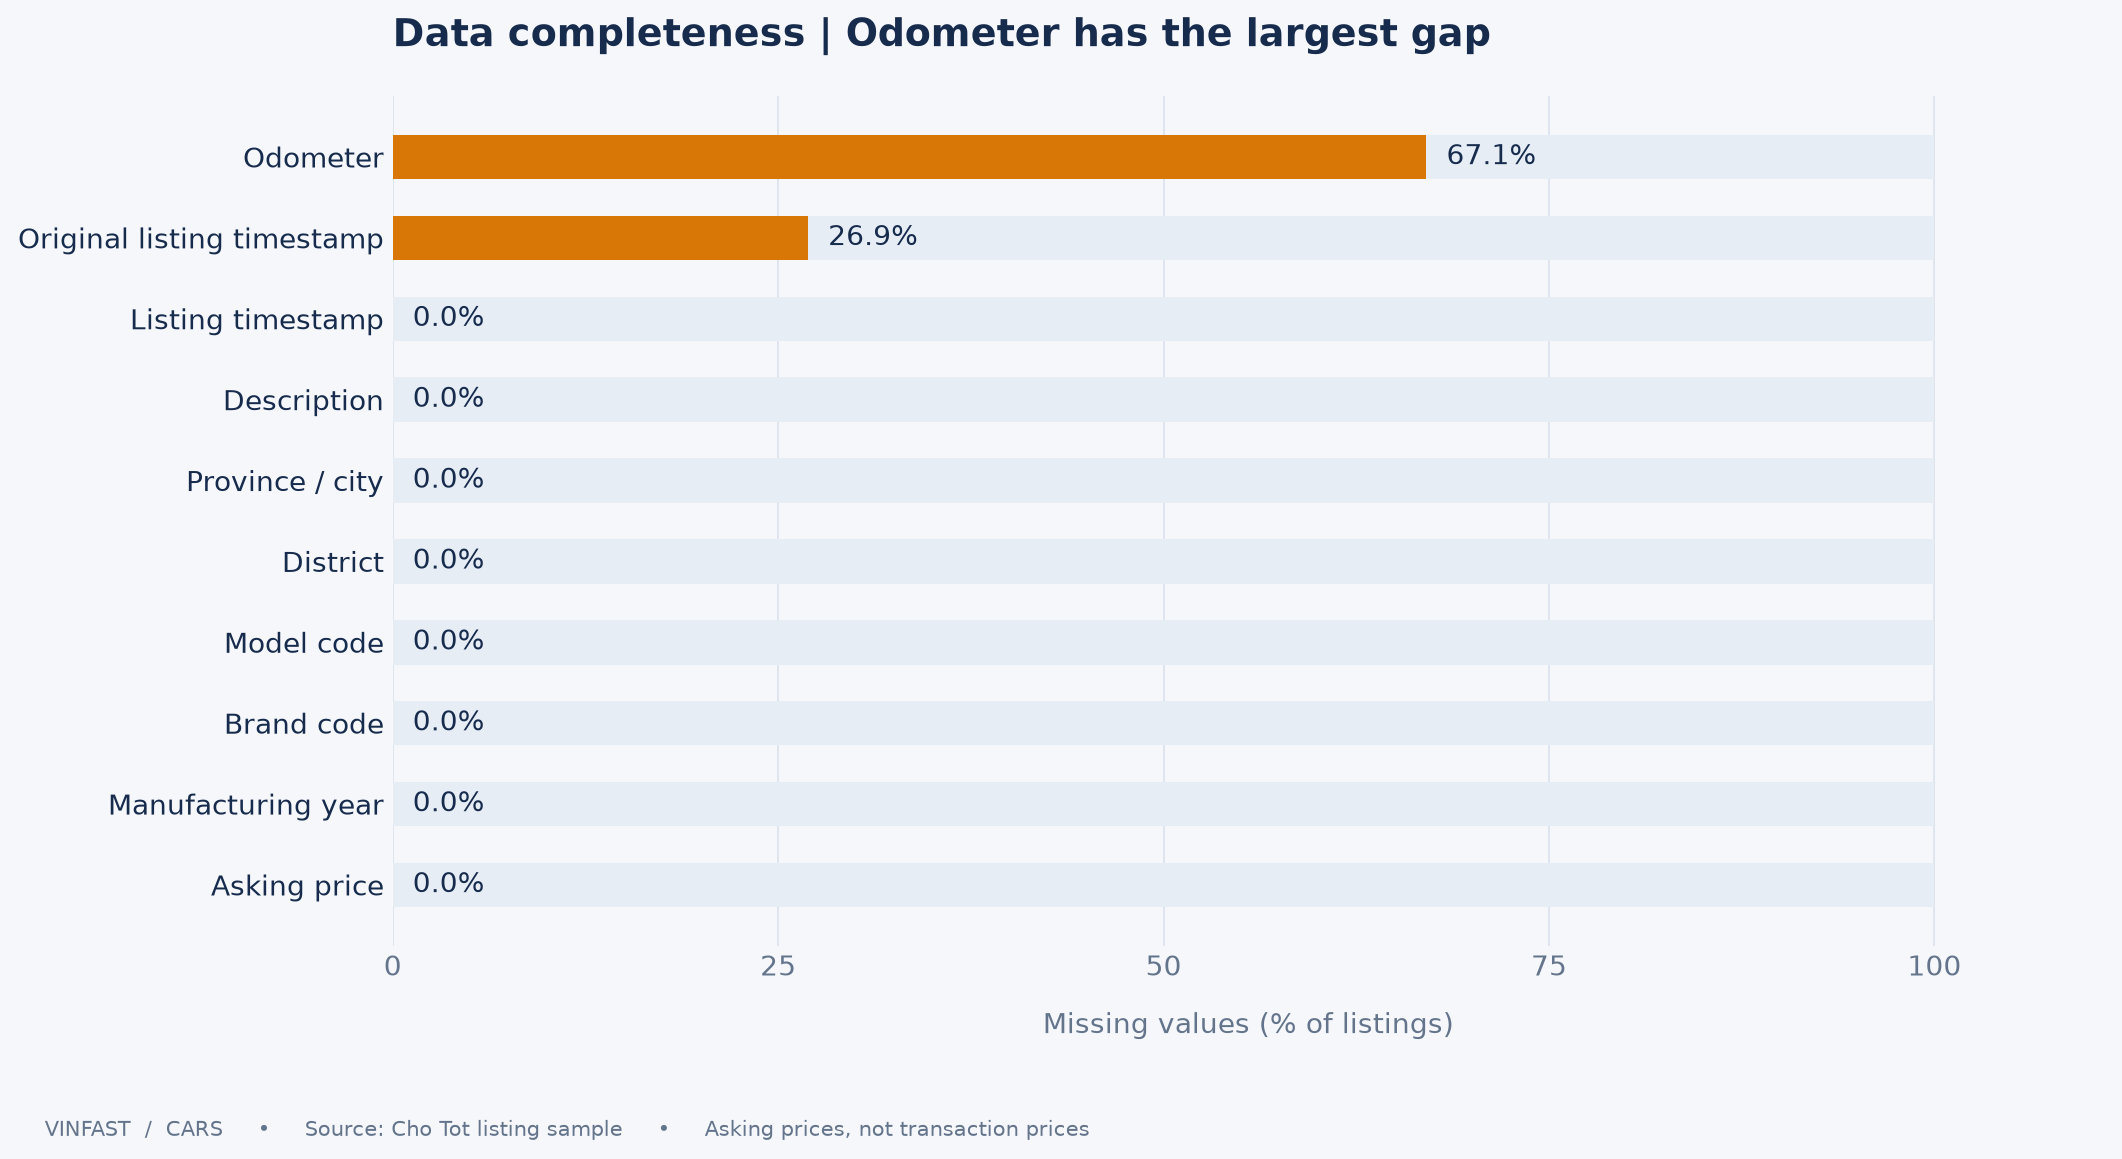

In [2]:
audit=[]
for name, df in tables.items():
    serialized = df.apply(lambda col: col.map(lambda v: json.dumps(v, sort_keys=True, ensure_ascii=False) if isinstance(v,(dict,list)) else v))
    has_id='list_id' in df
    audit.append({'file':name, 'rows':len(df), 'columns':len(df.columns),
                  'missing_listing_id':int(df.list_id.isna().sum()) if has_id else None,
                  'unique_listing_ids':df.list_id.nunique() if has_id else None,
                  'duplicate_id_rows':int(df.list_id.dropna().duplicated().sum()) if has_id else None,
                  'exact_duplicate_rows':int(serialized.duplicated().sum())})
audit=pd.DataFrame(audit)
display(audit)
all_cars=tables['chotot_oto_raw.json']
vinfast_mask=all_cars.carbrand_name.str.strip().str.casefold().eq('vinfast')
raws={'Ô tô VinFast':all_cars.loc[vinfast_mask].copy()}
note(f'**Phạm vi:** {len(all_cars):,} dòng ô tô → {int(vinfast_mask.sum()):,} dòng VinFast; loại {int((~vinfast_mask).sum()):,} dòng hãng khác khỏi EDA. Xe máy không tham gia.')
display(raws['Ô tô VinFast'][['carbrand','carbrand_name']].drop_duplicates())
assert raws['Ô tô VinFast'].carbrand.nunique()==1
work={}
for vehicle, raw in raws.items():
    d=raw.dropna(subset=['list_id']).drop_duplicates('list_id',keep='first').copy()
    d['brand_code']=d.carbrand.astype('Int64')
    d['model_code']=d.carmodel.astype('Int64')
    d['brand']=d.carbrand_name.fillna('Thiếu tên hãng')
    d['model']=d.brand+' '+d.carmodel_name.fillna('Thiếu tên mẫu')
    d['vehicle_year']=pd.to_numeric(d.mfdate,errors='coerce')
    for col in ['price','mileage_v2']: d[col]=pd.to_numeric(d[col],errors='coerce')
    d['condition']=d.condition_ad_name.fillna('Không rõ')
    # Consistent source v3 province/city labels; retain original in separate field.
    d['region_original']=d.region_name
    d['region']=d.region_name_v3.fillna(d.region_name).str.replace(r'^Tp\s+', 'TP ',regex=True).str.strip()
    d['body_clean']=d.body.fillna('').map(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
    work[vehicle]=d
    assert d.list_id.notna().all() and d.list_id.is_unique
    assert d.groupby(['brand_code','model_code']).model.nunique().le(1).all()
    note(f'**{vehicle}:** {len(raw):,} dòng → **{len(d):,} listing** sau quy tắc ID; chưa lọc theo giá/ODO.')
    note('**10 tin ngẫu nhiên kiểm tra nhãn nguồn (seed=42):**')
    display(d.sample(min(10,len(d)),random_state=42)[['list_id','subject','brand_code','model_code','brand','model']])
fields=['price','vehicle_year','mileage_v2','brand_code','model_code','region','area_name','body','orig_list_time','list_time']
missing=pd.DataFrame({v:d.reindex(columns=fields).isna().mean().mul(100) for v,d in work.items()}).T
display(missing.round(1))
names=['Asking price','Manufacturing year','Odometer','Brand code','Model code','Province / city','District','Description','Original listing timestamp','Listing timestamp']
s=pd.Series(missing.iloc[0].values,index=names).sort_values()
fig,ax=plt.subplots(figsize=(12,6.7))
ax.barh(s.index,[100]*len(s),color='#E7EDF5',height=.55)
bars=ax.barh(s.index,s.values,color=AMBER,height=.55)
ax.bar_label(bars,labels=[f'{v:.1f}%' for v in s],padding=8,color=INK)
ax.set(xlim=(0,111),xlabel='Missing values (% of listings)',title='Data completeness | Odometer has the largest gap')
ax.set_xticks([0,25,50,75,100]); ax.grid(axis='x')
save(fig,'01_missingness')

In [3]:
flags=[]
for vehicle,d in work.items():
    for col in ['price','mileage_v2']:
        s=d[col].dropna(); q1,q3=s.quantile([.25,.75]); iqr=q3-q1
        flags.append({'vehicle':vehicle,'field':col,'missing':int(d[col].isna().sum()),
          'negative':int((s<0).sum()),'zero':int((s==0).sum()),
          'IQR_outside':int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()),
          'min':s.min(),'p25':q1,'median':s.median(),'p75':q3,'max':s.max()})
display(pd.DataFrame(flags))
for vehicle,d in work.items():
    note(f'**{vehicle} — 5 mức giá thấp nhất để kiểm tra trả trước/giá mồi:**')
    display(d.nsmallest(5,'price')[['list_id','subject','price','condition','vehicle_year']])
    display(d.groupby(['brand_code','model_code']).size().describe().to_frame('số tin / cặp mã'))
note('**Diễn giải:** Ngoại lệ IQR chỉ là cờ kiểm tra, không bị xóa tự động. Giá thấp có thể là tiền trả trước; giá cao có thể là xe khác phân khúc. Thiếu ODO không được điền bằng 0. `mfdate` ô tô là năm sản xuất theo tên trường. Mã đầy đủ không đồng nghĩa nhãn người bán chọn chính xác.')
processed=tables['ev_market_cleaned.csv']
note(f'**Không dùng processed để ước lượng cơ cấu:** {len(processed):,} dòng nhưng chỉ {processed.list_id.nunique():,} ID. Ba nguồn B2C và benchmark không có cùng thiết kế mẫu với Cho Tot.')

,vehicle,field,missing,negative,zero,IQR_outside,min,p25,median,p75,max
0,Ô tô VinFast,price,0,0,2,32,0.0,278000000.0,570000000.0,679500000.0,1.699000e+09
1,Ô tô VinFast,mileage_v2,637,0,30,11,0.0,6000.0,20000.0,49000.0,1.000000e+06


**Ô tô VinFast — 5 mức giá thấp nhất để kiểm tra trả trước/giá mồi:**

,list_id,subject,price,condition,vehicle_year
313,134570732,VinFast MPV 7 2026 chỉ từ 7 Triệu/tháng,0,Mới,2026
316,134570744,VinFast Limo Green giảm hơn 50 triệu ko chính ...,0,Mới,2026
614,134511760,BẢO HIỂM BẮT BUỘC Ô TÔ GIÁ RẺ,5000000,Mới,2026
814,131776408,VinFast Minio bao nợ xấu - 13.5tr nhận xe ngay,13450000,Mới,2026
785,133274616,VinFast VF3 PLUS ĐỦ MÀU GIAO NGAY TỪ 50 TRIỆU,15000000,Mới,2026


,số tin / cặp mã
count,20.000000
mean,47.500000
std,51.573657
min,1.000000
25%,4.750000
50%,30.000000
75%,72.750000
max,178.000000


**Diễn giải:** Ngoại lệ IQR chỉ là cờ kiểm tra, không bị xóa tự động. Giá thấp có thể là tiền trả trước; giá cao có thể là xe khác phân khúc. Thiếu ODO không được điền bằng 0. `mfdate` ô tô là năm sản xuất theo tên trường. Mã đầy đủ không đồng nghĩa nhãn người bán chọn chính xác.

**Không dùng processed để ước lượng cơ cấu:** 1,000 dòng nhưng chỉ 50 ID. Ba nguồn B2C và benchmark không có cùng thiết kế mẫu với Cho Tot.

## 2. Cơ cấu nguồn cung

Mỗi listing có trọng số 1; số tin không phải số xe bán được hoặc số người mua. Cùng một xe có thể
được đăng với nhiều ID và chưa được phát hiện bằng khử trùng ID.
Top 12 chỉ hiển thị một phần danh mục; số lượng đầy đủ có trong bảng.
Vùng sử dụng `region_name_v3` do nguồn cung cấp, dự phòng `region_name`; giữ nhãn cũ để đối chiếu.
Đây là phân bố trong mẫu, không phải mật độ theo dân số hay độ phủ toàn thị trường.

,n,share_pct
model,,
VinFast VF3,178,18.74
VinFast VF8,128,13.47
VinFast Limo Green,124,13.05
VinFast VF6,98,10.32
VinFast VF5,78,8.21
VinFast VF5 Plus,71,7.47
VinFast VF7,67,7.05
VinFast VF9,57,6.00
VinFast MPV 7,32,3.37


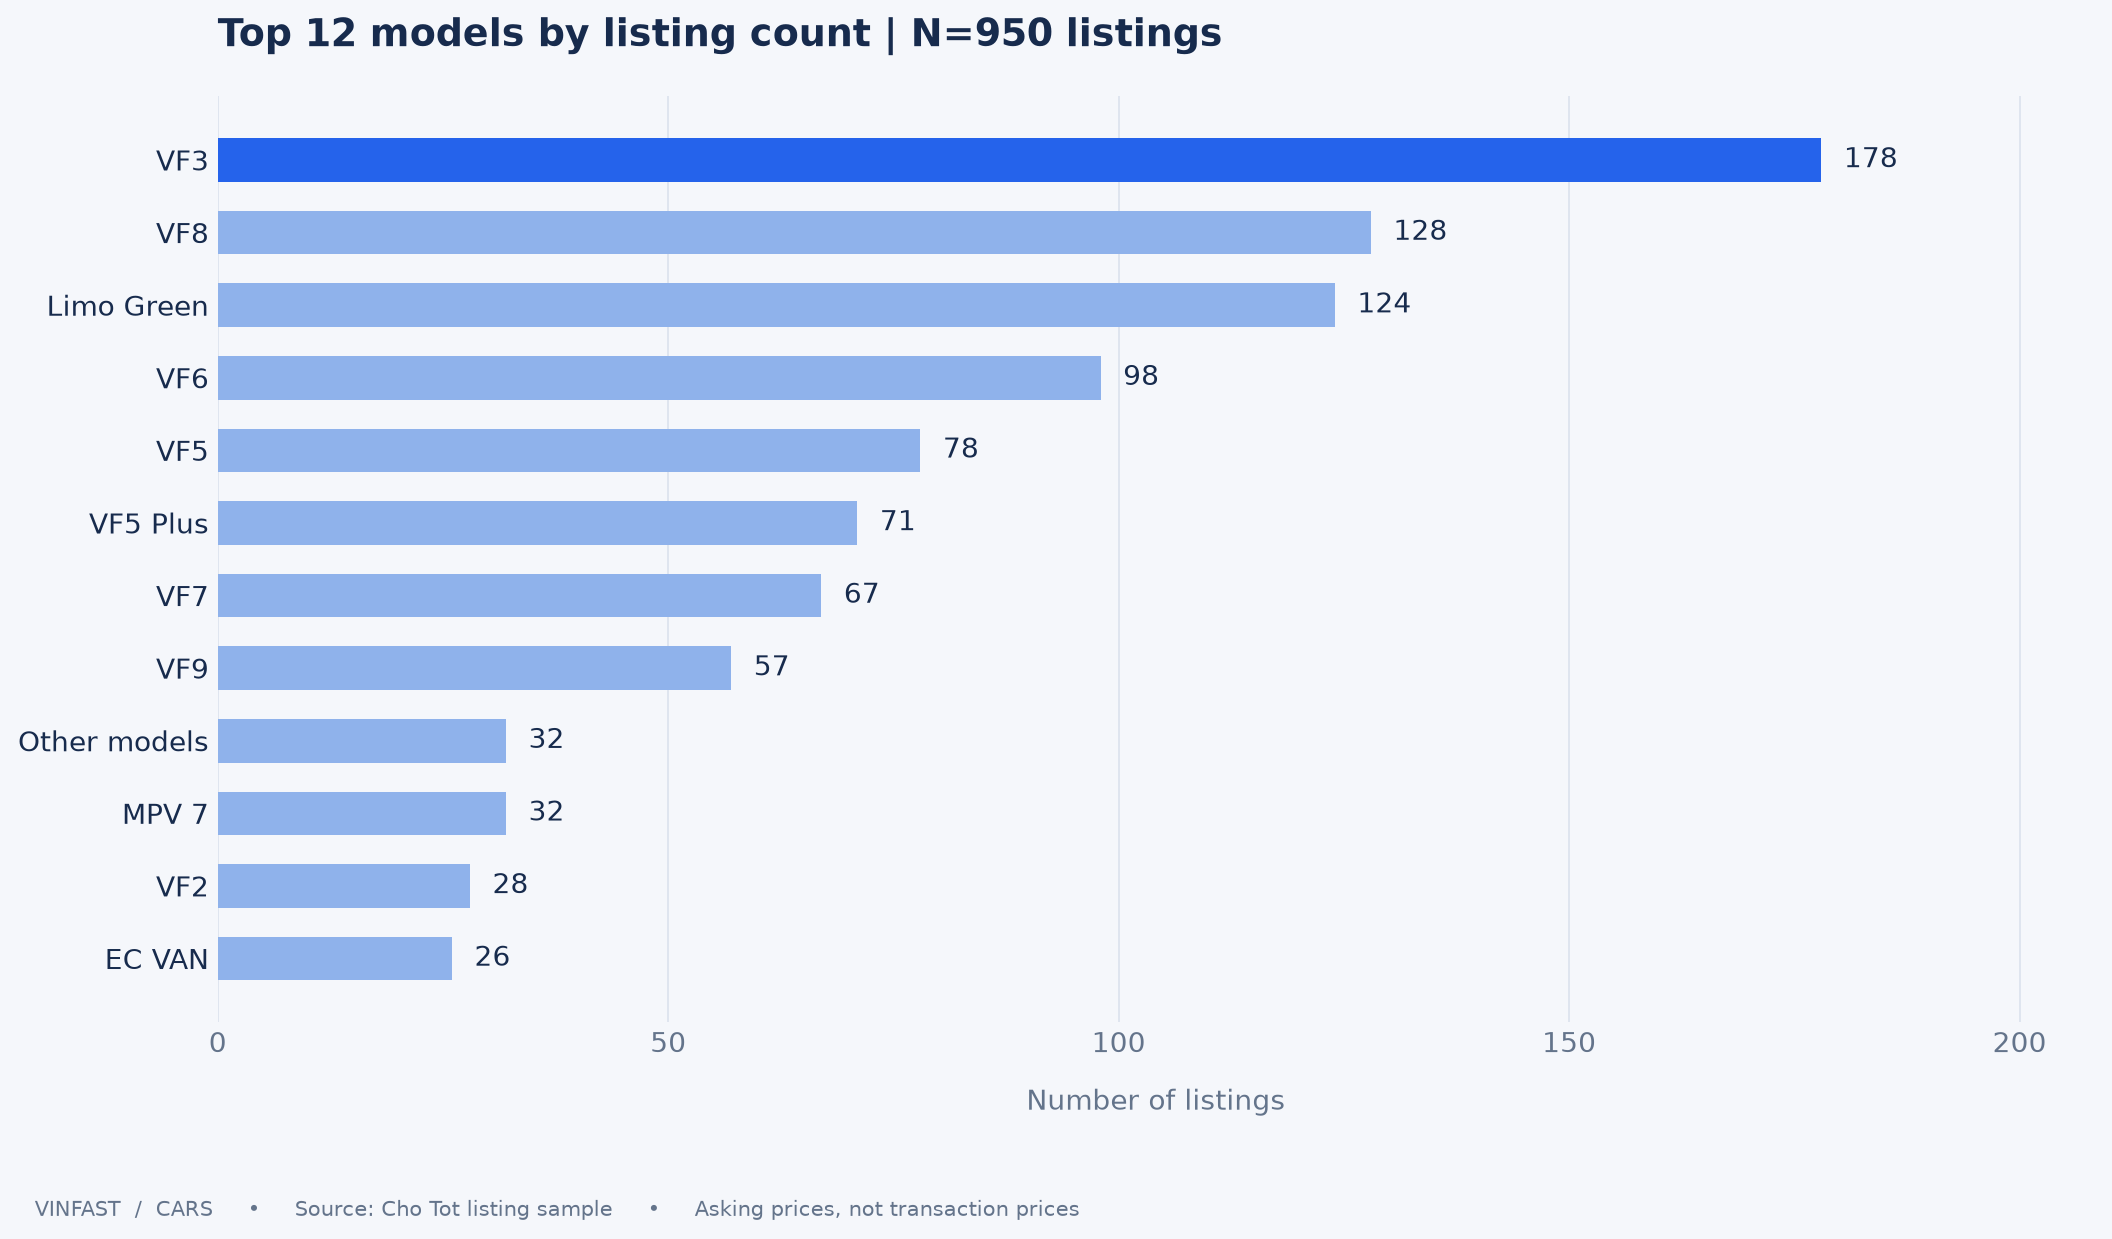

,n,share_pct
region,,
TP Hồ Chí Minh,671,70.63
TP Hà Nội,165,17.37
TP Đà Nẵng,44,4.63
Đồng Nai,22,2.32
TP Cần Thơ,22,2.32
Lâm Đồng,4,0.42
Tây Ninh,4,0.42
An Giang,2,0.21
Thanh Hóa,2,0.21


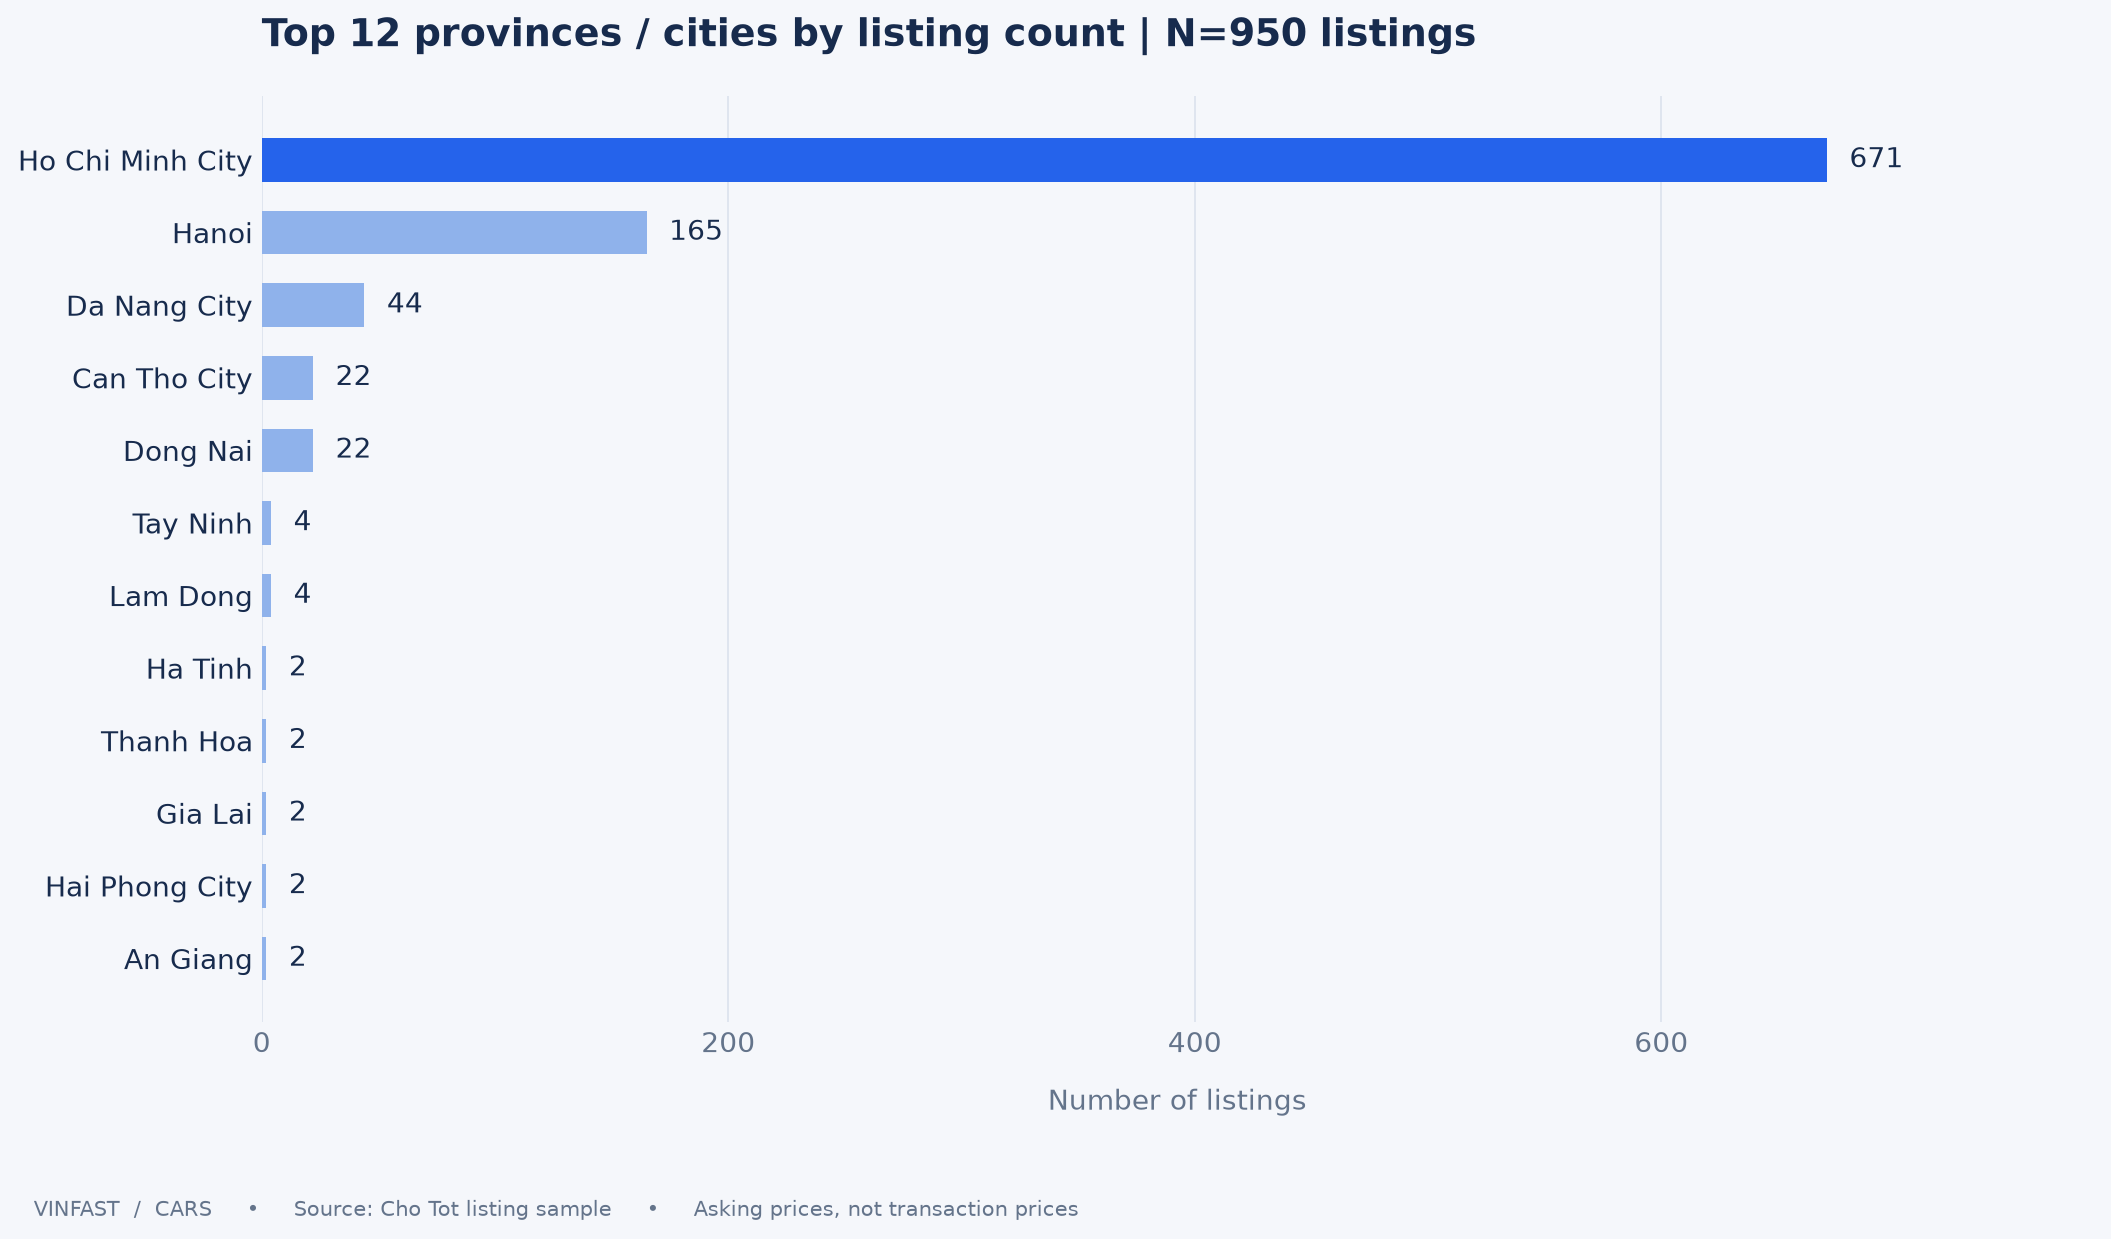

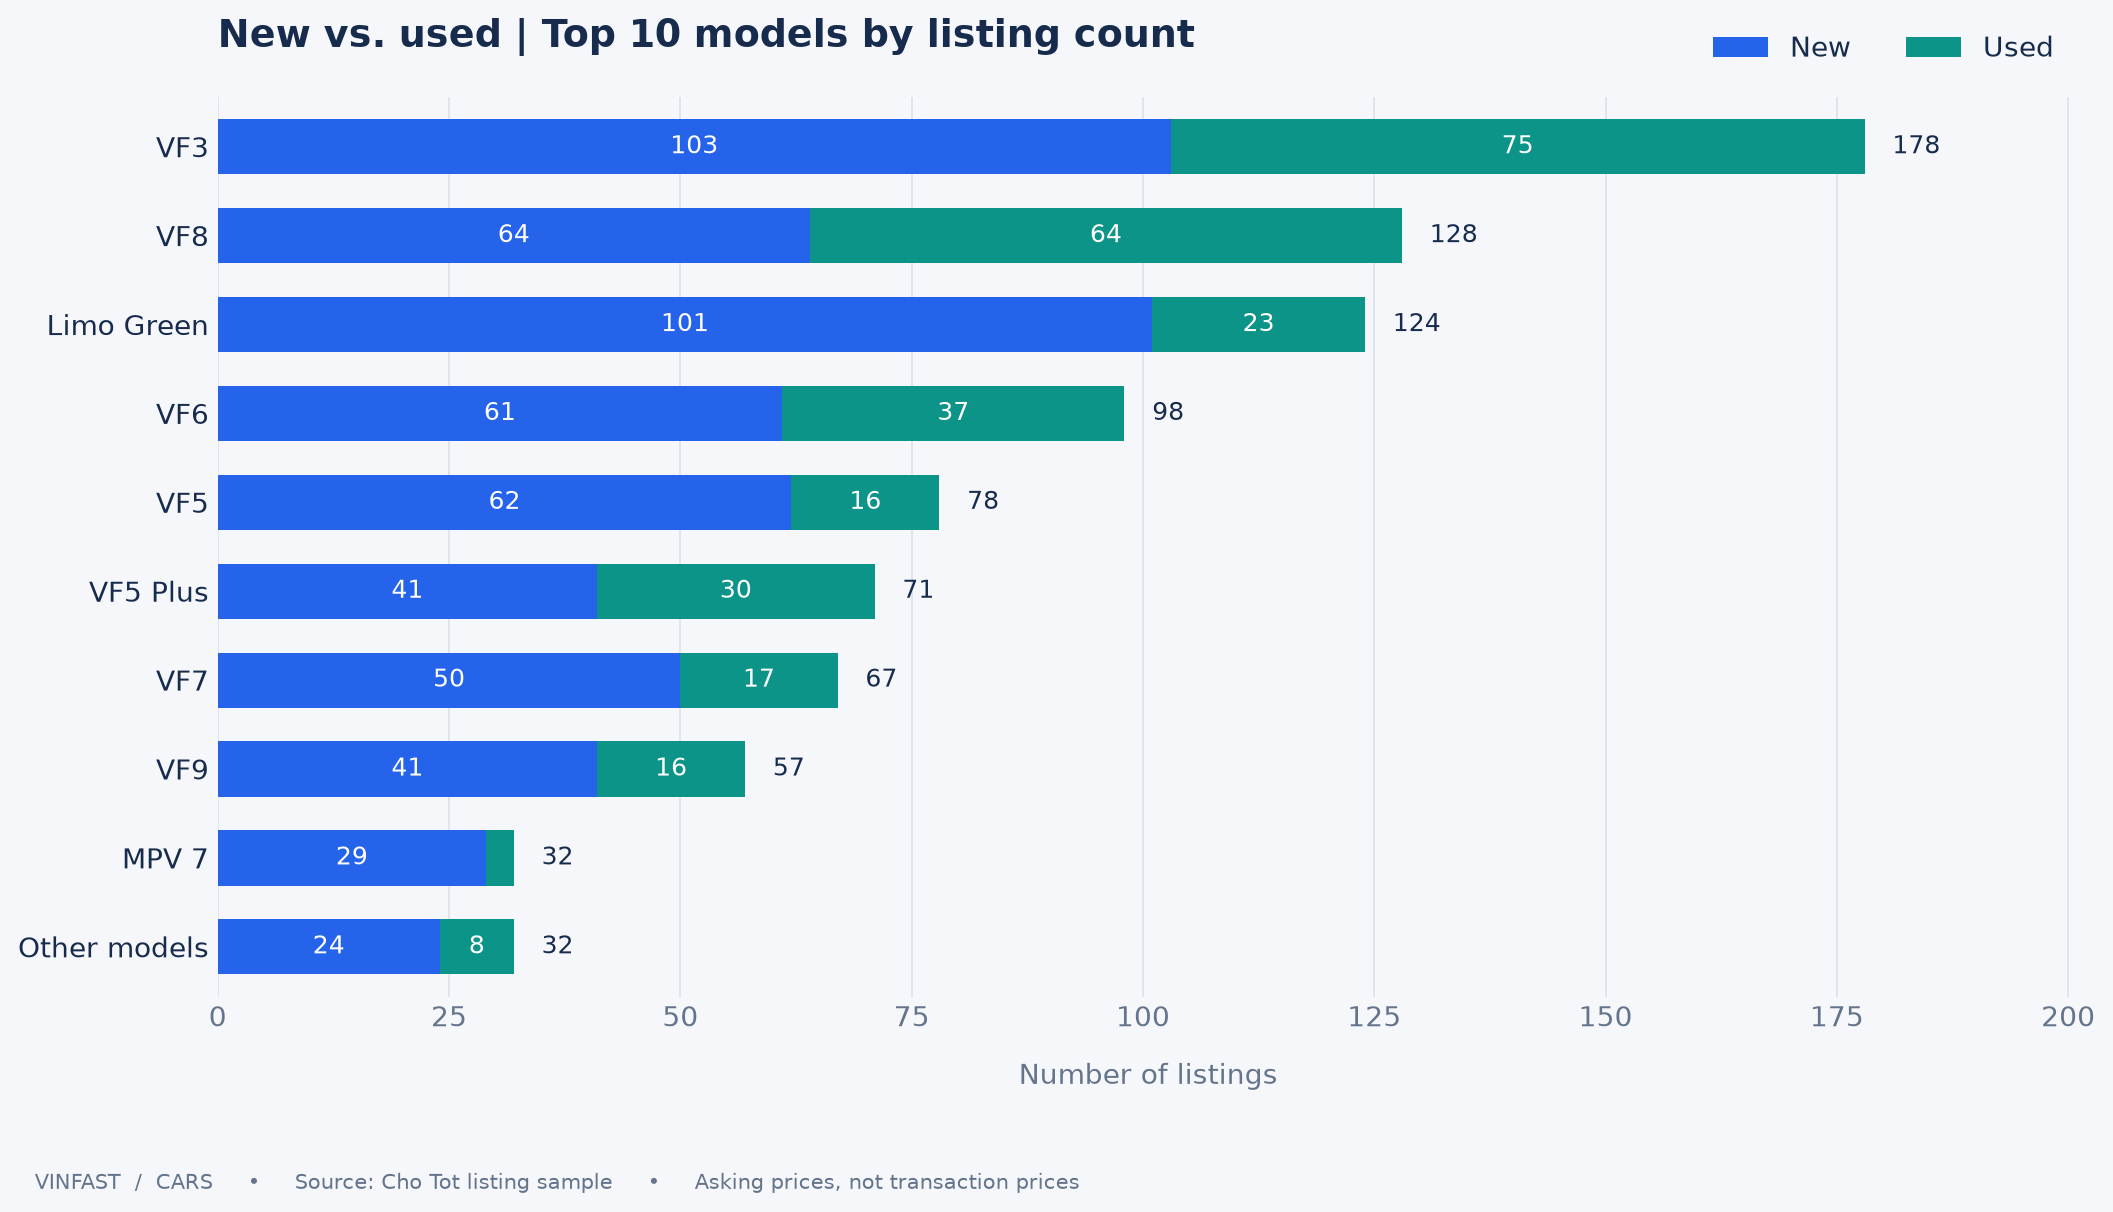

,n,share_pct
condition,,
Mới,641,67.47
Đã sử dụng,309,32.53


**Cơ cấu mẫu:** tình trạng phổ biến nhất là **Mới** (641 tin; 67.5%). Vùng nhiều tin nhất là **TP Hồ Chí Minh** (671 tin; 70.6%). Cả hai là cơ cấu tin đăng, không phải lựa chọn của người mua; mẫu tập trung theo địa lý có thể ảnh hưởng mặt bằng giá chung.

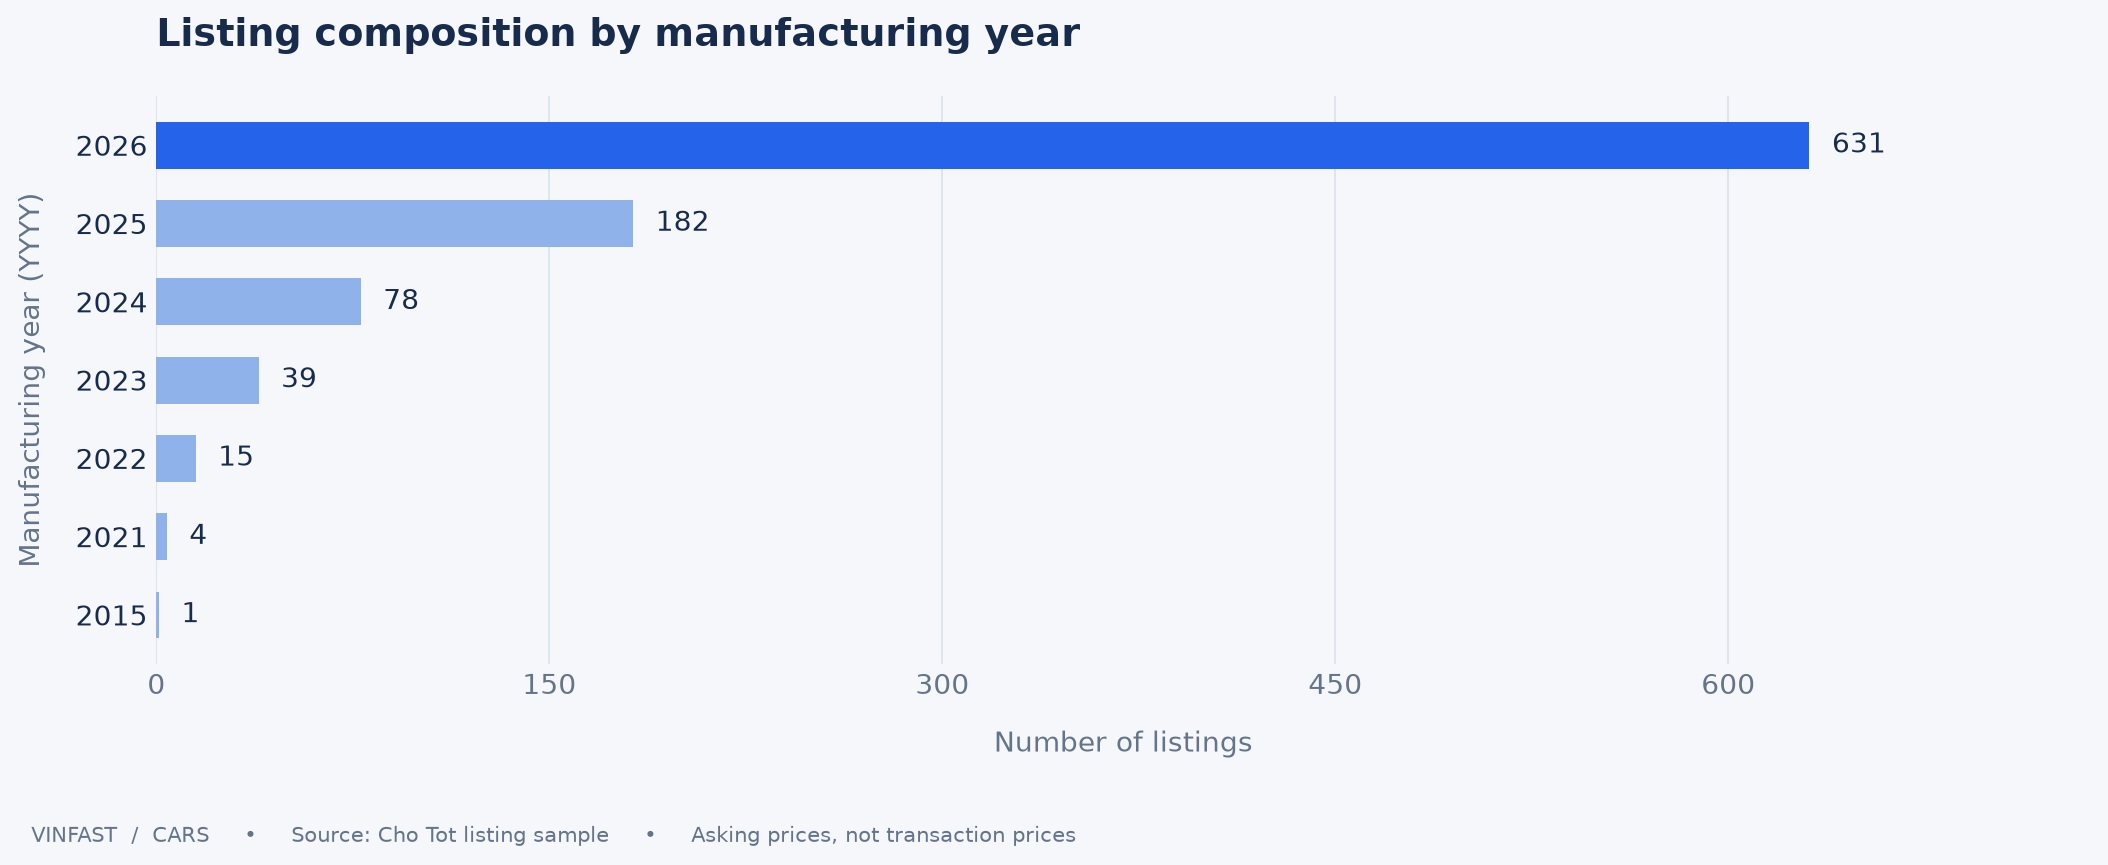

**Nhận xét Ô tô VinFast:** model nhiều tin nhất là **VinFast VF3**, 178/950 tin (18.7%). Top 3 model chiếm 45.3%. Đây là mức tập trung nguồn cung trong mẫu, không phải thị phần doanh số.

,region_original,region
36,An Giang,An Giang
572,Cà Mau,Cà Mau
312,Gia Lai,Gia Lai
631,Hà Tĩnh,Hà Tĩnh
910,Ninh Thuận,Khánh Hòa
78,Bình Thuận,Lâm Đồng
194,Lâm Đồng,Lâm Đồng
343,Vĩnh Phúc,Phú Thọ
193,Cần Thơ,TP Cần Thơ
0,Hà Nội,TP Hà Nội


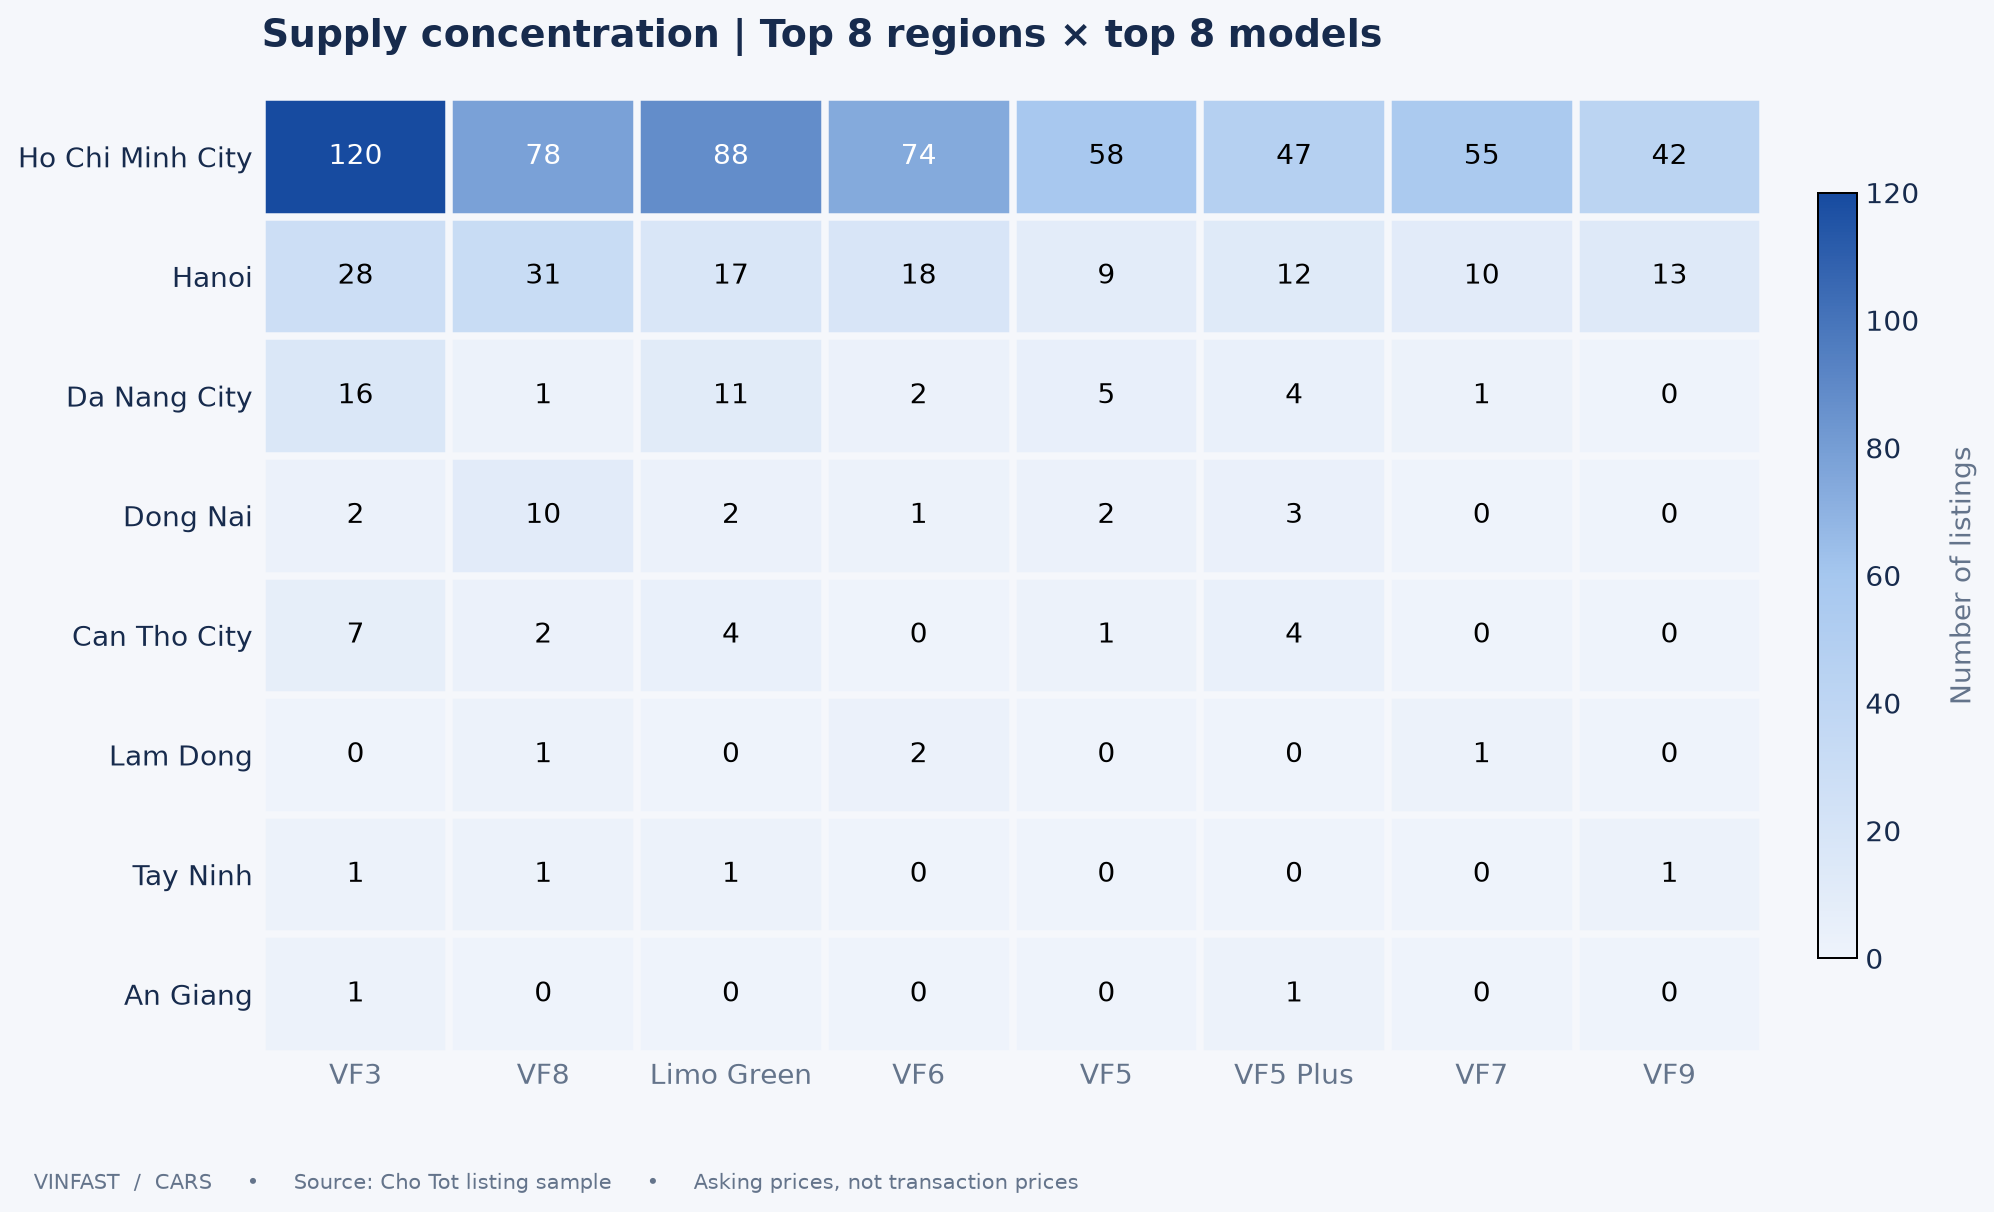

In [4]:
for vehicle,d in work.items():
    prefix='car'
    for field,label in [('model','models'),('region','provinces / cities')]:
        counts=d[field].value_counts(dropna=False)
        display(pd.DataFrame({'n':counts,'share_pct':counts/len(d)*100}).round(2))
        barh(counts.head(12),f'Top {min(12,len(counts))} {label} by listing count | N={len(d):,} listings','Number of listings',f'02_{prefix}_{field}')
    ct=pd.crosstab(d.model,d.condition)
    order=d.model.value_counts().head(10).index
    chart=ct.reindex(order[::-1]).rename(index=chart_label,columns=chart_label)
    ax=chart.plot.barh(stacked=True,figsize=(12,7),width=.62,color=[BLUE,TEAL,'#94A3B8'])
    for container in ax.containers:
        ax.bar_label(container,labels=[str(int(v)) if v>=8 else '' for v in container.datavalues],label_type='center',color='white',fontsize=10)
    for y,total in enumerate(chart.sum(axis=1)): ax.text(total+3,y,str(total),va='center',fontsize=10)
    ax.set(title='New vs. used | Top 10 models by listing count',xlabel='Number of listings',ylabel='',xlim=(0,chart.sum(axis=1).max()*1.13))
    ax.grid(axis='x')
    ax.legend(loc='lower right',ncols=2,bbox_to_anchor=(1,1.01))
    save(ax.figure,f'02_{prefix}_condition')
    conditions=d.condition.value_counts()
    display(pd.DataFrame({'n':conditions,'share_pct':conditions/len(d)*100}).round(2))
    regions=d.region.value_counts()
    note(f'**Cơ cấu mẫu:** tình trạng phổ biến nhất là **{conditions.index[0]}** ({conditions.iloc[0]:,} tin; {conditions.iloc[0]/len(d):.1%}). Vùng nhiều tin nhất là **{regions.index[0]}** ({regions.iloc[0]:,} tin; {regions.iloc[0]/len(d):.1%}). Cả hai là cơ cấu tin đăng, không phải lựa chọn của người mua; mẫu tập trung theo địa lý có thể ảnh hưởng mặt bằng giá chung.')
    years=d.vehicle_year.value_counts().sort_index()
    barh(years,'Listing composition by manufacturing year','Number of listings',f'02_{prefix}_year')
    leader=d.model.value_counts()
    note(f'**Nhận xét {vehicle}:** model nhiều tin nhất là **{leader.index[0]}**, {leader.iloc[0]:,}/{len(d):,} tin ({leader.iloc[0]/len(d):.1%}). Top 3 model chiếm {leader.head(3).sum()/len(d):.1%}. Đây là mức tập trung nguồn cung trong mẫu, không phải thị phần doanh số.')
    display(d[['region_original','region']].drop_duplicates().sort_values(['region','region_original']))
    region_models=pd.crosstab(d.region,d.model).reindex(index=d.region.value_counts().head(8).index,columns=d.model.value_counts().head(8).index,fill_value=0)
    fig,ax=plt.subplots(figsize=(12,7))
    im=ax.imshow(region_models,cmap=LinearSegmentedColormap.from_list('market',['#EEF3FB','#A6C7EF','#174BA0']),aspect='auto')
    ax.set_xticks(range(len(region_models.columns)),[chart_label(s) for s in region_models.columns],rotation=0)
    ax.set_yticks(range(len(region_models)),[chart_label(s) for s in region_models.index])
    for i in range(len(region_models)):
        for j in range(len(region_models.columns)):
            n=region_models.iloc[i,j]
            ax.text(j,i,str(n),ha='center',va='center',color='white' if n>region_models.to_numpy().max()/2 else 'black')
    ax.set_title('Supply concentration | Top 8 regions × top 8 models')
    ax.set_xticks(np.arange(len(region_models.columns)+1)-.5,minor=True)
    ax.set_yticks(np.arange(len(region_models)+1)-.5,minor=True)
    ax.grid(which='minor',color='#F5F7FB',linewidth=3); ax.tick_params(which='minor',length=0)
    fig.colorbar(im,ax=ax,label='Number of listings',shrink=.8,pad=.03)
    save(fig,'02_car_region_model')

## 3. Mặt bằng giá chào bán

Giá nguồn là VND; biểu đồ chuyển sang triệu đồng. Chỉ loại giá thiếu/không dương khỏi đồ thị giá,
ghi số loại ra; không cắt ngọn phân phối và không tự xóa ngoại lệ. Báo cáo median, P25–P75 và n.
Boxplot chỉ hiển thị các model có ít nhất 10 quan sát giá, tối đa 10 model nhiều tin nhất.
Giá quảng cáo có thể là giá trả trước hoặc tùy điều kiện pin, cần đọc tin để xác minh.
Không gán tứ phân vị giá thành phân khúc nhu cầu gia đình/đô thị/phổ thông.

**Ô tô VinFast:** dùng 948/950 tin có giá dương; loại khỏi đồ thị 2 tin giá thiếu/không dương.

,n,median,p25,p75,minimum,maximum
model,,,,,,
VinFast VF3,178,268.52,235.00,278.00,5.00,740.0
VinFast VF8,128,799.50,670.00,848.00,90.00,1348.0
VinFast Limo Green,123,639.00,605.50,662.00,42.00,848.0
VinFast VF6,98,600.00,565.25,631.50,430.00,688.0
VinFast VF5,78,436.00,407.00,471.00,34.44,659.0
VinFast VF5 Plus,71,400.00,355.00,435.50,30.00,644.0
VinFast VF7,67,725.00,684.50,740.00,80.00,1068.0
VinFast VF9,57,1289.00,1185.00,1348.00,229.00,1699.0
VinFast Dòng khác,32,644.00,365.75,698.50,15.00,758.0


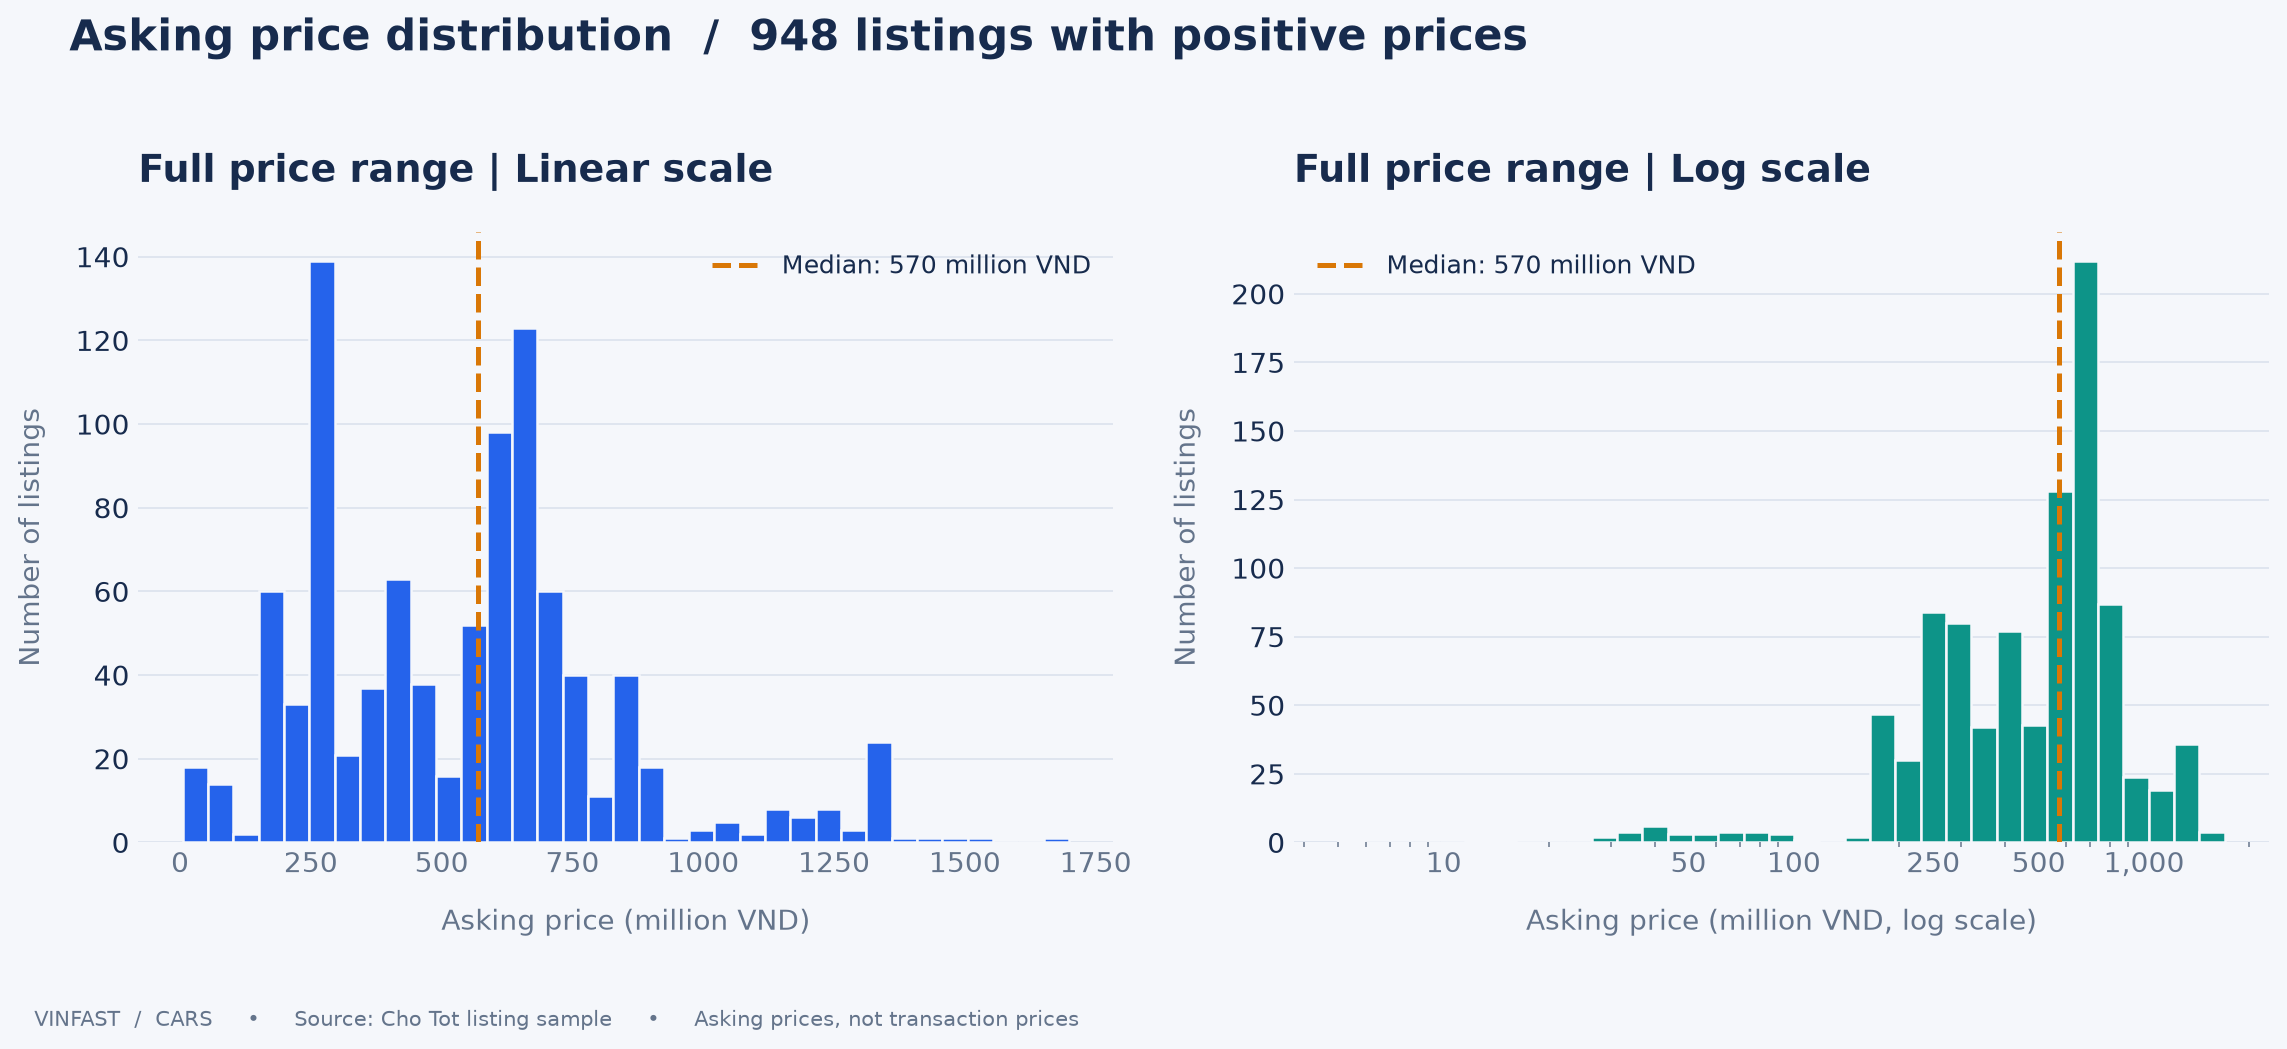

C:\Users\Admin\AppData\Local\Temp\ipykernel_20812\935847808.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([p.loc[p.model.eq(m),'price_million'] for m in eligible],vert=False,


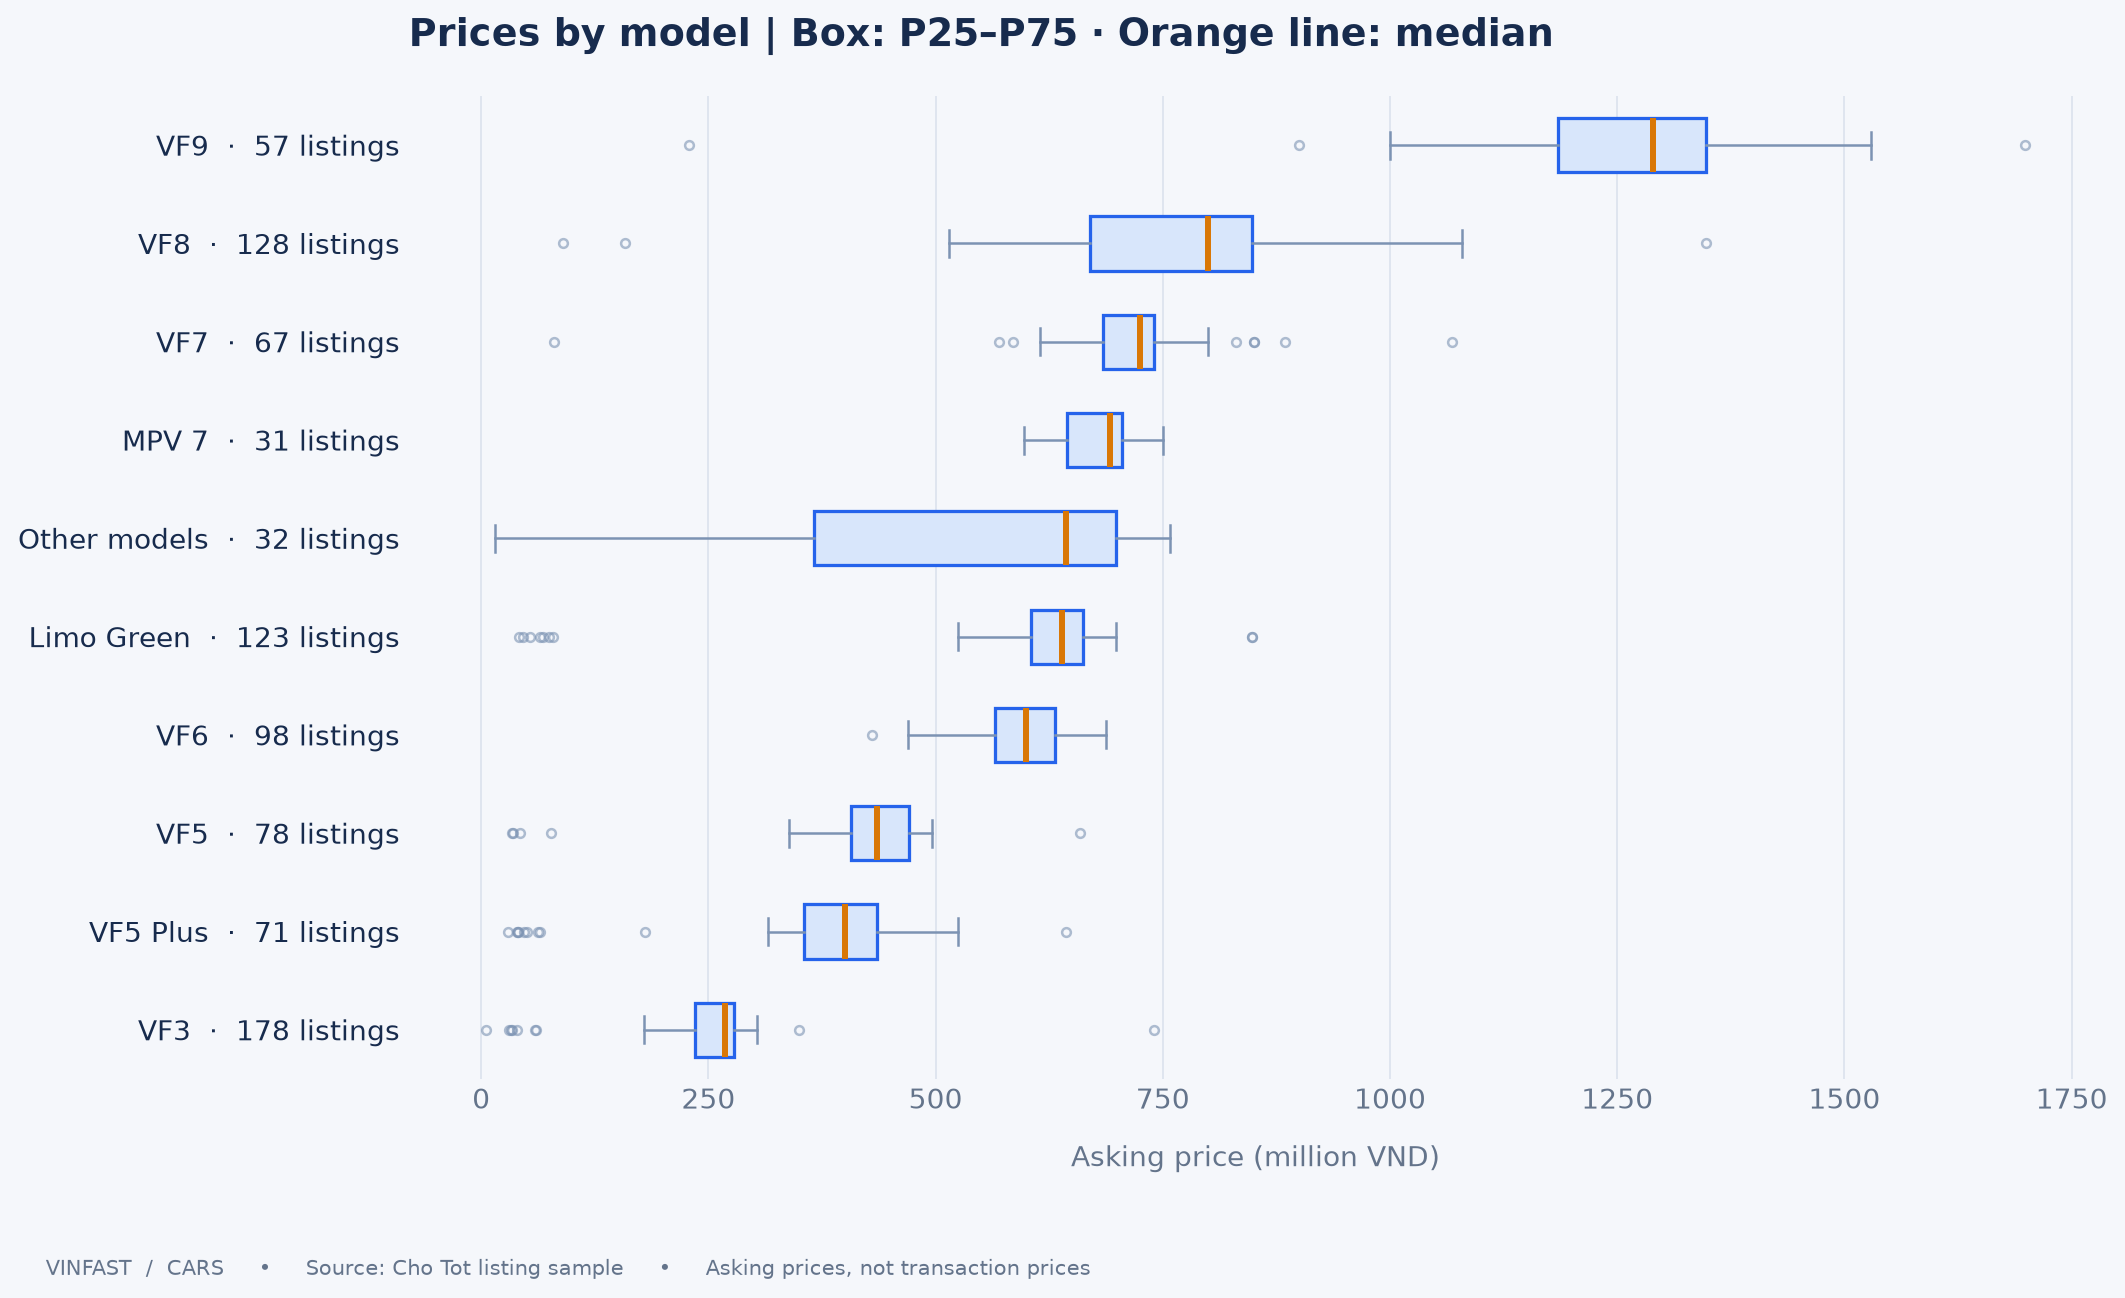

,n,median,p25,p75
condition,,,,
Mới,639,595.0,278.0,699.5
Đã sử dụng,309,539.0,270.0,650.0


n  median      p25      p75
model               condition                                
VinFast Dòng khác   Mới          24   650.0   187.25   718.75
                    Đã sử dụng    8   631.0   563.75   689.25
VinFast EC VAN      Mới          25   248.0   248.00   268.00
                    Đã sử dụng    1   306.0   306.00   306.00
VinFast Fadil       Đã sử dụng    1   295.0   295.00   295.00
VinFast Herio Green Mới           5   397.0   325.00   420.00
                    Đã sử dụng    1   359.0   359.00   359.00
VinFast Limo Green  Mới         100   644.0   620.00   664.00
                    Đã sử dụng   23   615.0   587.50   622.50
VinFast Lux SA2.0   Đã sử dụng    1   525.0   525.00   525.00
VinFast MPV 7       Mới          28   693.0   650.00   707.50
                    Đã sử dụng    3   640.0   637.50   645.00
VinFast Minio Green Mới           7   180.0   141.50   182.00
                    Đã sử dụng    4   188.0   183.00   188.00
VinFast Nerio Green Đã sử dụng    1   450.0   450.00   450.00
VinFast President   Đã sử dụng    1  1050.0  1050.00  1050.00
VinFast VF2         Mới          28   180.0   179.42   180.00
VinFast VF3         Mới         103   278.0   268.02   279.00
                    Đã sử dụng   75   248.0   209.00   263.50
VinFast VF5         Mới          62   439.0   425.00   471.00
                    Đã sử dụng   16   366.5   350.00   408.75
VinFast VF5 Plus    Mới          41   431.0   380.00   440.00
                    Đã sử dụng   30   367.5   331.25   390.00
VinFast VF6         Mới          61   615.0   586.00   646.00
                    Đã sử dụng   37   565.0   536.00   608.00
VinFast VF7         Mới          50   730.0   700.00   740.00
                    Đã sử dụng   17   690.0   639.00   739.00
VinFast VF8         Mới          64   848.0   829.50   898.00
                    Đã sử dụng   64   676.5   608.75   745.00
VinFast VF8 Lux     Đã sử dụng    1   750.0   750.00   750.00
VinFast VF9         Mới          41  1348.0  1245.00  1348.00
                    Đã sử dụng   16  1160.0  1140.00  1191.25
VinFast VFe34       Đã sử dụng    9   350.0   350.00   369.00

,n,median,p25,p75
region,,,,
TP Hồ Chí Minh,669,573.0,279.00,693.00
TP Hà Nội,165,590.0,326.00,680.00
TP Đà Nẵng,44,431.5,268.75,640.92
Đồng Nai,22,622.5,362.50,684.75
TP Cần Thơ,22,135.0,43.50,251.50
Lâm Đồng,4,560.0,485.00,653.75
Tây Ninh,4,767.0,551.00,1010.50
Vĩnh Long,2,255.0,221.50,288.50
Gia Lai,2,270.0,232.50,307.50


n  median
vehicle_year condition             
2015         Đã sử dụng   1   250.0
2024         Đã sử dụng  21   199.0
2025         Mới          7   244.0
             Đã sử dụng  48   255.0
2026         Mới         96   278.0
             Đã sử dụng   5   270.0

**Độ phủ ODO:** toàn bộ VinFast thiếu 637/950 giá trị (67.1%); scatter chỉ dùng 75/178 tin của VinFast VF3. Không thể giả định nhóm khai báo ODO đại diện cho nhóm không khai báo.

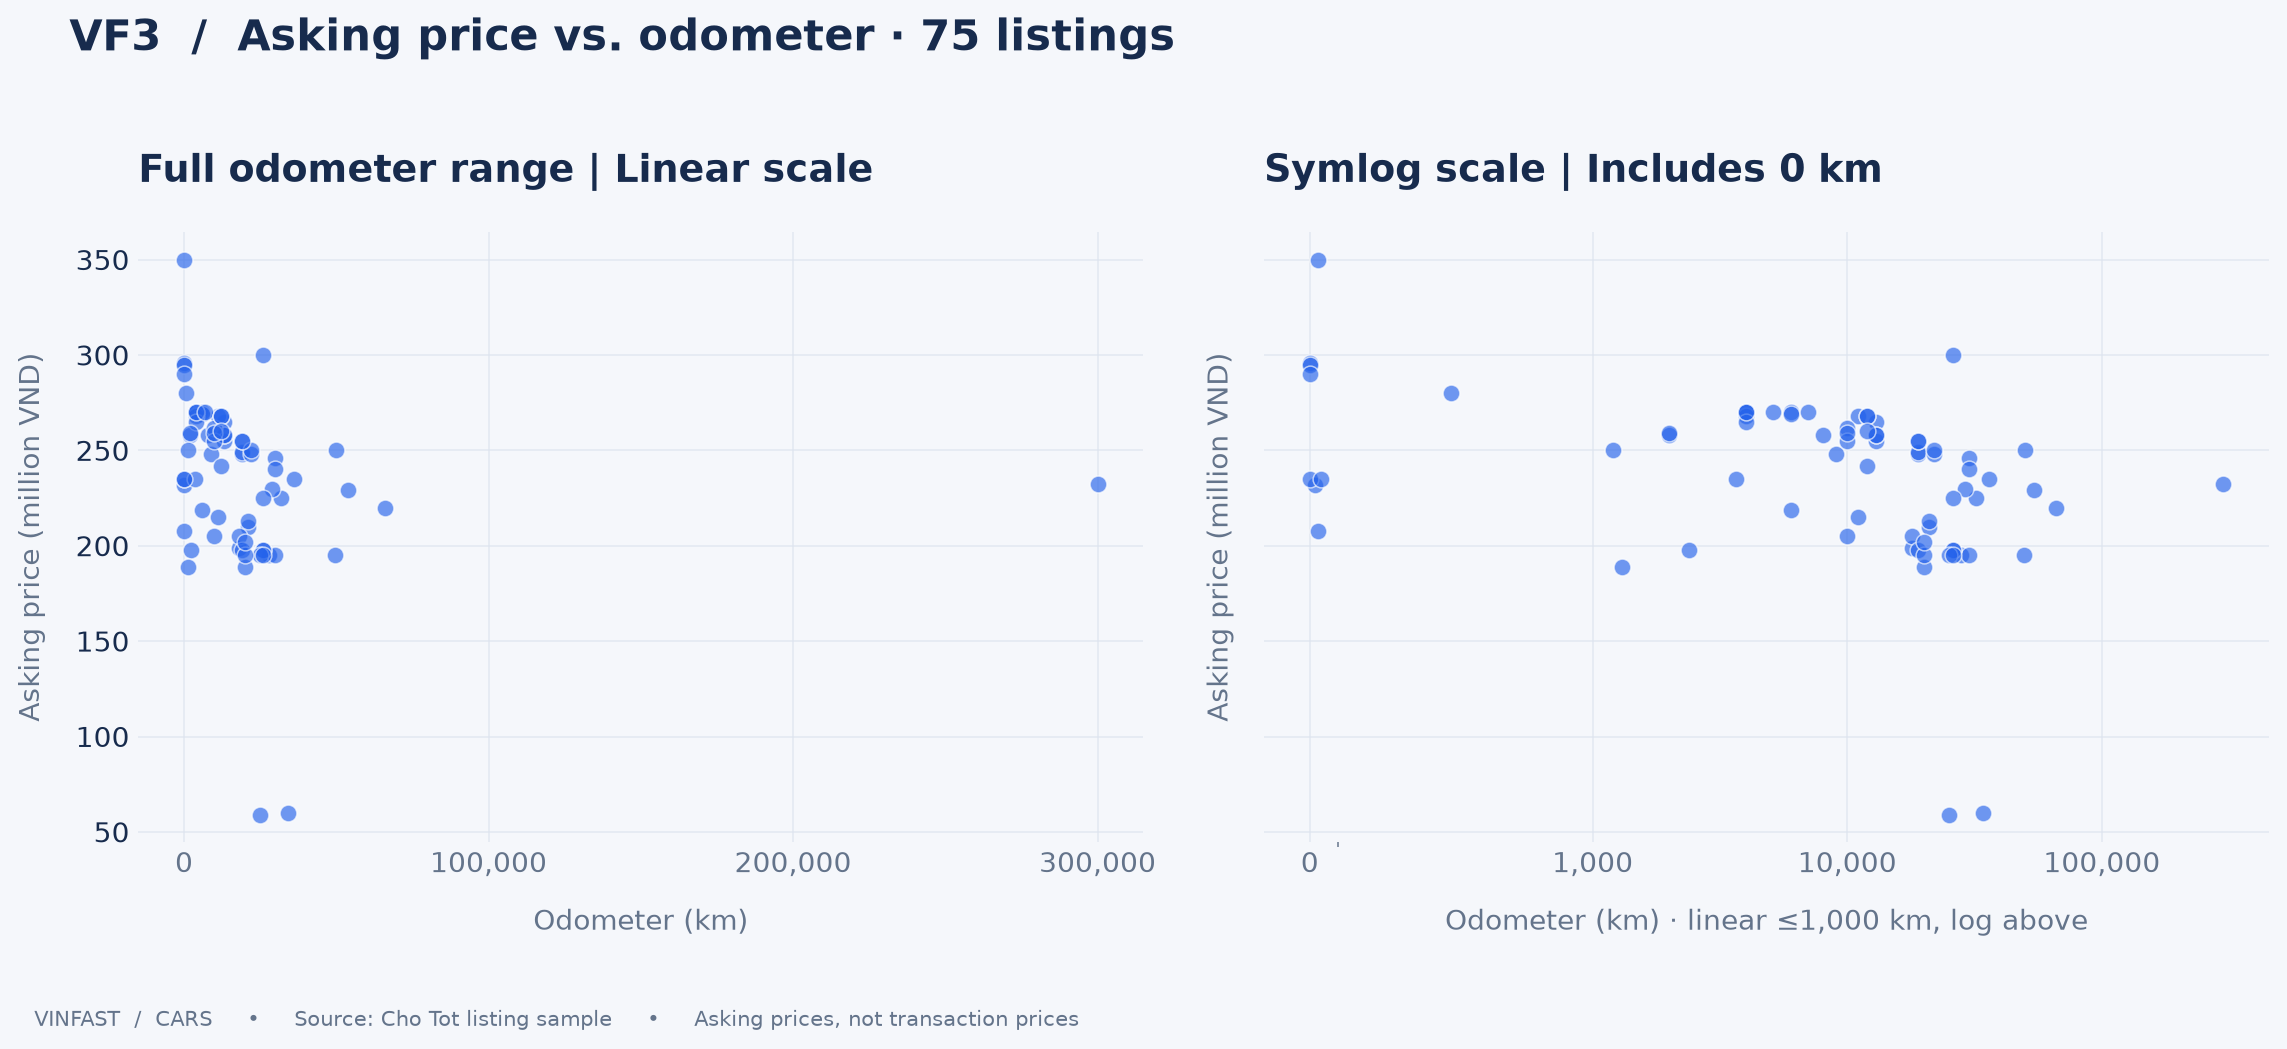

**Nhận xét Ô tô VinFast:** median toàn mẫu **570.00 triệu VND**, khoảng giữa 50% tin **278.00–680.00 triệu**. So sánh mới/cũ toàn mẫu chịu ảnh hưởng cơ cấu model và năm xe; scatter không chứng minh tác động khấu hao. Model nhiều tin nhất dùng ở scatter là VinFast VF3; thiếu ODO bị loại riêng khỏi scatter, không coi là 0 km.

In [5]:
price_summaries={}
for vehicle,d in work.items():
    prefix='car'
    p=d.loc[d.price.gt(0)].copy(); p['price_million']=p.price/1e6
    note(f'**{vehicle}:** dùng {len(p):,}/{len(d):,} tin có giá dương; loại khỏi đồ thị {len(d)-len(p):,} tin giá thiếu/không dương.')
    stats=p.groupby('model').price_million.agg(n='size',median='median',p25=lambda s:s.quantile(.25),p75=lambda s:s.quantile(.75),minimum='min',maximum='max').sort_values('n',ascending=False)
    price_summaries[vehicle]=stats
    display(stats.round(2))
    fig,axes=plt.subplots(1,2,figsize=(13,5.8))
    axes[0].hist(p.price_million,bins=35,color=BLUE,edgecolor='#F5F7FB',linewidth=1)
    axes[0].set(title='Full price range | Linear scale',xlabel='Asking price (million VND)',ylabel='Number of listings')
    axes[1].hist(p.price_million,bins=np.geomspace(p.price_million.min(),p.price_million.max(),36),color=TEAL,edgecolor='#F5F7FB',linewidth=1)
    axes[1].set_xscale('log')
    axes[1].set(title='Full price range | Log scale',xlabel='Asking price (million VND, log scale)',ylabel='Number of listings')
    axes[1].set_xticks([10,50,100,250,500,1000]); axes[1].xaxis.set_major_formatter(FuncFormatter(lambda v,pos:f'{v:,.0f}'))
    for ax in axes:
        ax.axvline(p.price_million.median(),color=AMBER,lw=2,ls='--',label=f'Median: {p.price_million.median():,.0f} million VND')
        ax.legend(fontsize=10); ax.grid(axis='y')
    fig.suptitle(f'Asking price distribution  /  {len(p):,} listings with positive prices',fontsize=17,fontweight='bold',x=.04,ha='left')
    save(fig,f'03_{prefix}_price_distribution')
    eligible=stats.loc[stats.n.ge(10)].head(10).sort_values('median').index
    if len(eligible):
        fig,ax=plt.subplots(figsize=(12,7.5))
        ax.boxplot([p.loc[p.model.eq(m),'price_million'] for m in eligible],vert=False,
                   tick_labels=[f'{chart_label(m)}  ·  {stats.loc[m,"n"]:.0f} listings' for m in eligible],showfliers=True,patch_artist=True,widths=.55,
                   boxprops={'facecolor':'#D8E6FB','edgecolor':BLUE,'linewidth':1.3},
                   medianprops={'color':AMBER,'linewidth':2.4},whiskerprops={'color':'#7C93B3'},capprops={'color':'#7C93B3'},
                   flierprops={'marker':'o','markersize':3.5,'markeredgecolor':'#7C93B3','alpha':.6})
        ax.grid(axis='x')
        ax.set(xlabel='Asking price (million VND)',title='Prices by model | Box: P25–P75 · Orange line: median')
        save(fig,f'03_{prefix}_model_prices')
    display(p.groupby('condition').price_million.agg(n='size',median='median',p25=lambda s:s.quantile(.25),p75=lambda s:s.quantile(.75)).round(2))
    display(p.groupby(['model','condition']).price_million.agg(n='size',median='median',p25=lambda s:s.quantile(.25),p75=lambda s:s.quantile(.75)).round(2))
    display(p.groupby('region').price_million.agg(n='size',median='median',p25=lambda s:s.quantile(.25),p75=lambda s:s.quantile(.75)).sort_values('n',ascending=False).round(2))
    # Conditional views avoid treating mixed models as a depreciation estimate.
    common=p.model.value_counts().index[0]
    m=p.loc[p.model.eq(common)]
    display(m.groupby(['vehicle_year','condition']).price_million.agg(n='size',median='median').round(2))
    od=m.loc[m.mileage_v2.ge(0)]
    note(f'**Độ phủ ODO:** toàn bộ VinFast thiếu {d.mileage_v2.isna().sum():,}/{len(d):,} giá trị ({d.mileage_v2.isna().mean():.1%}); scatter chỉ dùng {len(od)}/{len(m)} tin của {common}. Không thể giả định nhóm khai báo ODO đại diện cho nhóm không khai báo.')
    fig,axes=plt.subplots(1,2,figsize=(13,5.8),sharey=True)
    for ax in axes:
        ax.scatter(od.mileage_v2,od.price_million,alpha=.65,s=45,color=BLUE,edgecolors='white',linewidth=.6)
        ax.set(xlabel='Odometer (km)',ylabel='Asking price (million VND)')
        ax.grid(alpha=.65)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v,pos:f'{v:,.0f}'))
    axes[0].set_title('Full odometer range | Linear scale')
    axes[0].xaxis.set_major_locator(MaxNLocator(4))
    axes[1].set_xscale('symlog',linthresh=1000)
    axes[1].set_xticks([0,1000,10000,100000])
    axes[1].set_title('Symlog scale | Includes 0 km')
    axes[1].set_xlabel('Odometer (km) · linear ≤1,000 km, log above')
    axes[1].xaxis.set_major_formatter(FuncFormatter(lambda v,pos:f'{v:,.0f}'))
    fig.suptitle(f'{chart_label(common)}  /  Asking price vs. odometer · {len(od)} listings',fontsize=17,fontweight='bold',x=.04,ha='left')
    save(fig,f'03_{prefix}_price_odo')
    q=p.price_million.quantile([.25,.5,.75])
    note(f'**Nhận xét {vehicle}:** median toàn mẫu **{q.loc[.5]:.2f} triệu VND**, khoảng giữa 50% tin **{q.loc[.25]:.2f}–{q.loc[.75]:.2f} triệu**. So sánh mới/cũ toàn mẫu chịu ảnh hưởng cơ cấu model và năm xe; scatter không chứng minh tác động khấu hao. Model nhiều tin nhất dùng ở scatter là {common}; thiếu ODO bị loại riêng khỏi scatter, không coi là 0 km.')

## 4. Thông điệp bán hàng

Quy tắc từ khóa chỉ áp dụng cho `subject + body`, **không dùng để suy brand/model**.
Gắn nhiều nhãn trên một tin là hợp lệ: tổng tỷ lệ có thể vượt 100%.
Những nhãn này nghĩa là “có nhắc đến”, không xác nhận ưu đãi còn hiệu lực hay tình trạng pin thực tế.
Chuẩn hóa bỏ dấu và chữ thường để tìm cụm từ. Đính kèm pattern và ví dụ để kiểm tra sai dương/sai âm.
Không gọi kết quả này là sentiment, ý định mua hay hiệu quả khuyến mãi.

,Regex trên văn bản không dấu
Nhắc kèm/mua pin,\b(kem pin|bao pin|gom pin|mua pin|pin mua|da ...
Nhắc thuê pin,\b(thue pin|pin thue)\b
Nhắc trả góp/trả trước,\b(tra gop|tra truoc|gop 0|lai suat)\b
Nhắc khuyến mãi,\b(khuyen mai|khuyen mai|uu dai|giam gia|ctkm|...
Nhắc đổi xe xăng,"\b(doi|thu|thu cu doi moi)\b.{0,60}\bxe xang\b..."
Nhắc bảo hành/hậu mãi,\b(bao hanh|hau mai|bao duong|bao tri)\b


C:\Users\Admin\AppData\Local\Temp\ipykernel_20812\3973992341.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  flags=pd.DataFrame({label:text.str.contains(pattern,regex=True) for label,pattern in patterns.items()},index=d.index)


,tin_co_nhac,pct_all_listings
Nhắc khuyến mãi,514,54.11
Nhắc trả góp/trả trước,449,47.26
Nhắc bảo hành/hậu mãi,290,30.53
Nhắc đổi xe xăng,180,18.95
Nhắc kèm/mua pin,128,13.47
Nhắc thuê pin,35,3.68


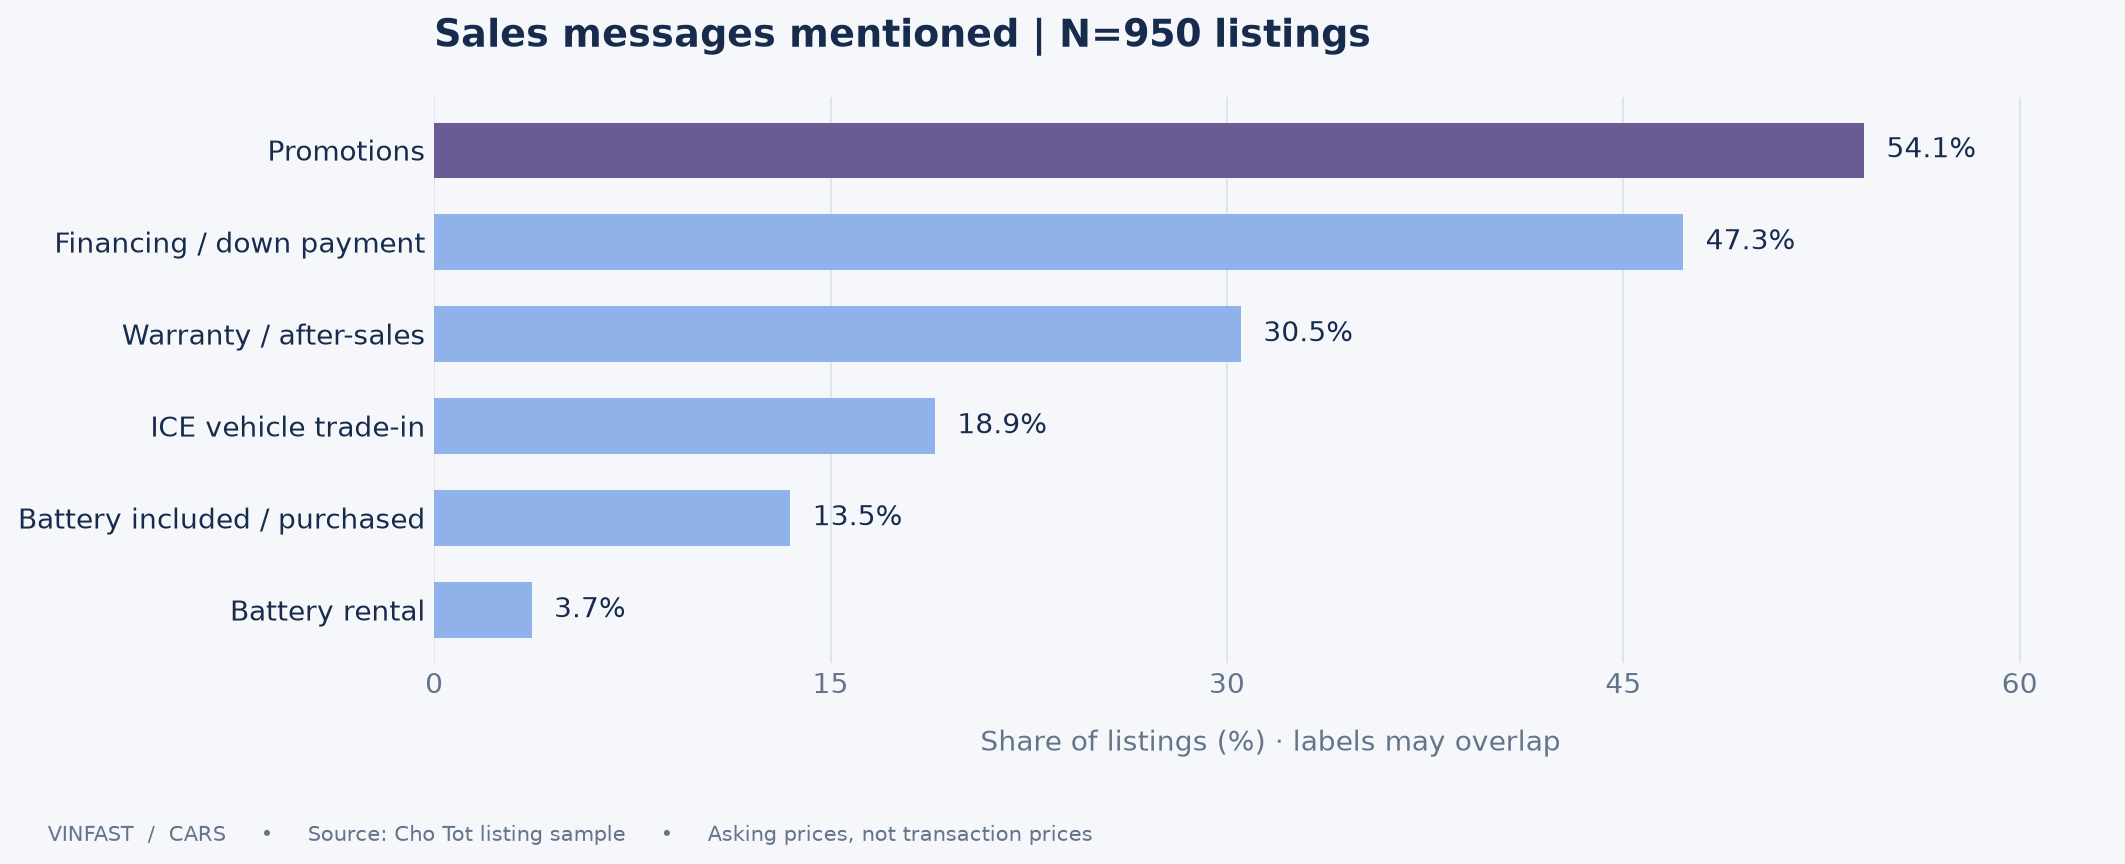

,nhan,list_id,subject,doan_khop_khong_dau
0,Nhắc kèm/mua pin,134599448,VF8 mua pin CALT chạy hơn 4v đen quyền lực,vf8 mua pin calt chay hon 4v den quyen luc 🔥 v...
1,Nhắc kèm/mua pin,133050802,VF8 Plus 2022 xe mua đứt Pin đẹp xuất sắc,"dep xuat sac chi 6xx cho ae! ban cao cap nhat,..."
2,Nhắc kèm/mua pin,134597265,VinFast VF5 Plus 2024 Xám Điện,"t vf5 plus 2024 xam dien vf5 plus, san xuat 20..."
3,Nhắc thuê pin,134599448,VF8 mua pin CALT chạy hơn 4v đen quyền lực,"xe sach dep 🔋 da mua pin catl, khoi lan tan t..."
4,Nhắc thuê pin,134609331,VinFast VF3 2024 Vàng Điện,vinfast vf3 2024 vang dien vf3 2024 thue pin 2...
5,Nhắc thuê pin,134631673,VinFast VF3 2024 Vàng 30.000km,dk thang 12/2024 di duoc 30.000km gia 195tr (...
6,Nhắc trả góp/trả trước,134518548,"VinFast VF3 Eco, Plus Điện đủ mẫu mã giá sập sàn🚨",ach uu dai:⚡mien phi sac den 02/2029 • ho tro ...
7,Nhắc trả góp/trả trước,134331029,VinFast VF 3 PLUS Đỏ SẴN XE GIAO NGAY TRẢ TRƯỚ...,vinfast vf 3 plus do san xe giao ngay tra truo...
8,Nhắc trả góp/trả trước,134608049,"VinFast LimoGreen, trả trước 84tr, nhận xe ngay","vinfast limogreen, tra truoc 84tr, nhan xe nga..."
9,Nhắc khuyến mãi,134599448,VF8 mua pin CALT chạy hơn 4v đen quyền lực,xe xang: van giam 80 trieu ⚠ xe dep + pin cat...


**Kiểm tra Ô tô VinFast:** 9 tin cùng nhắc mua/kèm pin và thuê pin. Có thể là mô tả lựa chọn hoặc phủ định; không tự gán tình trạng pin độc quyền.

**Nhận xét Ô tô VinFast:** thông điệp phổ biến nhất theo bộ quy tắc là **Nhắc khuyến mãi**, 514 tin (54.1%). Đây là kết quả của bộ từ khóa công khai, chưa phải nhãn đã kiểm định thủ công.

In [6]:
def normalize(text):
    text=unicodedata.normalize('NFD',str(text).lower().replace('đ','d'))
    return re.sub(r'\s+',' ', ''.join(c for c in text if unicodedata.category(c)!='Mn'))
patterns={
 'Nhắc kèm/mua pin':r'\b(kem pin|bao pin|gom pin|mua pin|pin mua|da mua pin)\b',
 'Nhắc thuê pin':r'\b(thue pin|pin thue)\b',
 'Nhắc trả góp/trả trước':r'\b(tra gop|tra truoc|gop 0|lai suat)\b',
 'Nhắc khuyến mãi':r'\b(khuyen mai|khuyen mai|uu dai|giam gia|ctkm|voucher|khuyen ma[iy])\b',
 'Nhắc đổi xe xăng':r'\b(doi|thu|thu cu doi moi)\b.{0,60}\bxe xang\b|\bxe xang\b.{0,60}\b(doi|voucher|ho tro|giam)\b',
 'Nhắc bảo hành/hậu mãi':r'\b(bao hanh|hau mai|bao duong|bao tri)\b'
}
display(pd.Series(patterns,name='Regex trên văn bản không dấu').to_frame())
for vehicle,d in work.items():
    prefix='car'
    text=(d.subject.fillna('')+' '+d.body.fillna('')).map(normalize)
    flags=pd.DataFrame({label:text.str.contains(pattern,regex=True) for label,pattern in patterns.items()},index=d.index)
    counts=flags.sum().sort_values(ascending=False)
    display(pd.DataFrame({'tin_co_nhac':counts,'pct_all_listings':counts/len(d)*100}).round(2))
    barh(counts/len(d)*100,f'Sales messages mentioned | N={len(d):,} listings','Share of listings (%) · labels may overlap',f'04_{prefix}_messages','#6B5B95')
    examples=[]
    for label,pattern in patterns.items():
        # First three matches per label, with matched span in normalized text.
        for ix in flags.index[flags[label]][:3]:
            match=re.search(pattern,text.loc[ix]); start,end=match.span()
            examples.append({'nhan':label,'list_id':d.loc[ix,'list_id'],'subject':d.loc[ix,'subject'],
                             'doan_khop_khong_dau':text.loc[ix][max(0,start-50):end+80]})
    display(pd.DataFrame(examples))
    both=flags['Nhắc kèm/mua pin'] & flags['Nhắc thuê pin']
    note(f'**Kiểm tra {vehicle}:** {int(both.sum())} tin cùng nhắc mua/kèm pin và thuê pin. Có thể là mô tả lựa chọn hoặc phủ định; không tự gán tình trạng pin độc quyền.')
    note(f'**Nhận xét {vehicle}:** thông điệp phổ biến nhất theo bộ quy tắc là **{counts.index[0]}**, {counts.iloc[0]} tin ({counts.iloc[0]/len(d):.1%}). Đây là kết quả của bộ từ khóa công khai, chưa phải nhãn đã kiểm định thủ công.')

## Tổng hợp và giới hạn sử dụng

- Dùng kết quả để mô tả **mẫu tin đăng đang có**, lựa chọn nhóm model cần khảo sát và xác định
  vùng giá chào bán để đọc sâu; không suy rộng thành thị phần doanh số.
- Ô tô VinFast có tên model từ trường nguồn; đây là nhãn người đăng chọn, chưa xác minh bằng thông số xe. Xe máy nằm ngoài phạm vi.
- Không trộn B2C/benchmark vào Cho Tot: nguồn và đơn vị quan sát khác nhau.
- Không có snapshot lặp lại/crawl timestamp đáng tin cậy: không tính tăng trưởng hoặc thanh khoản.
- Phần giá giữ cả tin có khả năng quảng cáo trả trước; đọc các tin giá thấp đã in ở mục 1
  trước khi dùng kết quả để định giá. Thiếu năm hiệu lực của benchmark cũng hạn chế so sánh.
- Các ví dụ từ khóa là mẫu kiểm tra, không đo precision/recall. Cần gán nhãn thủ công
  một mẫu độc lập nếu muốn sử dụng feature thông điệp cho mô hình tiếp theo.

**Điều kiện trước bước phân tích tiếp theo:** xác minh nhãn model ô tô, ý nghĩa năm xe,
giá toàn xe so với trả trước, và chọn phiên bản địa giới hành chính. Không cần đổi tên mã bằng phỏng đoán.

In [7]:
assert all(hashlib.sha256(Path(p).read_bytes()).hexdigest()==h for p,h in hashes.items()), 'Source changed'
assert all(d.list_id.is_unique for d in work.values())
assert len(saved)==len(set(saved)) and all(p.stat().st_size>1000 for p in saved)
note(f'**Kiểm tra hoàn tất:** {len(sources)} file nguồn giữ nguyên SHA-256; ID bảng VinFast không trùng; **{len(saved)} ảnh PNG** đã lưu. Không xuất/ghi đè staging hay merge nguồn.')
display(pd.DataFrame({'figure':[p.relative_to(ROOT).as_posix() for p in saved]}))

**Kiểm tra hoàn tất:** 7 file nguồn giữ nguyên SHA-256; ID bảng VinFast không trùng; **10 ảnh PNG** đã lưu. Không xuất/ghi đè staging hay merge nguồn.

,figure
0,figures/01_missingness.png
1,figures/02_car_model.png
2,figures/02_car_region.png
3,figures/02_car_condition.png
4,figures/02_car_year.png
5,figures/02_car_region_model.png
6,figures/03_car_price_distribution.png
7,figures/03_car_model_prices.png
8,figures/03_car_price_odo.png
9,figures/04_car_messages.png
